# Nanoplasma reduced-H5 plotting notebook (no openPMD)

This notebook reproduces the main paper-style plots **directly from the reduced HDF5 files**.

Expected top-level H5 groups:
`axes`, `timeseries`, `spectra`, `radial`, `slices`, (optional) `macrocell3d`, (optional) `meta`

---

## What is possible from your current reduced H5?

Given your inventory:

- **Figure 1 storyboard (maps)** ✅ from `/slices`
- **Ne(t), dNe/dt** ✅ from `/timeseries/He_e_N_real` (or `N_macro`)
- **Mean energies / temperatures** ✅ from `/timeseries/*Ekin*`, `*T_mean_eV`, `*T_tail_eV`
- **Charge-state evolution** ✅ from `/timeseries/He_i_charge_frac`, `/timeseries/He_i_Z_mean`, and `/radial/He_i_charge_rZ_counts`
- **Radial expansion (R(t), mean radius, rms)** ✅ from `/radial/He_i_n_r` and `axes/r_mid_m`
- **Net charge vs radius/time** ✅ from `/radial/rho_net_shell_C` + `shell_volume_m3` (see notes in code)
- **Electron & ion spectra heatmaps** ✅ from `/spectra/*_dNdE` and `axes/E_mid_eV`
- **Angular (mu) heatmap + asymmetry** ✅ from `/spectra/He_e_dNdmu` and `axes/mu_mid`
- **Phase shift of plasma dipole vs laser field** ❌ not possible unless you also store a time-resolved dipole moment `d(t)` and laser field `E(t)` (or a proxy at the droplet center). You can add those to the exporter later.

If you later add `spectra/*_H_pxy` (2D momentum histogram), this notebook includes an optional VMI panel.


In [4]:
import h5py
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

# ---------- USER INPUT ----------
H5_IONIZED = r"/p/scratch/jureap18/medina2/2026_nanoplasma/Run004_reducedV2.h5"
H5_NEUTRAL = r"/p/scratch/jureap18/medina2/2026_nanoplasma/Run004_reduced_log.h5"   # neutral-start
# --------------------------------

def h5_inventory(path):
    with h5py.File(path, "r") as f:
        inv = {}
        for k in f.keys():
            inv[k] = list(f[k].keys()) if isinstance(f[k], h5py.Group) else []
        return inv

def h5_read(path, dset):
    with h5py.File(path, "r") as f:
        return np.array(f[dset])

def h5_has(path, dset):
    with h5py.File(path, "r") as f:
        return dset in f

def load_axes(path):
    axes = {}
    with h5py.File(path, "r") as f:
        for k in f["axes"].keys():
            axes[k] = np.array(f["axes"][k])
    return axes

def load_timeseries(path):
    ts = {}
    with h5py.File(path, "r") as f:
        for k in f["timeseries"].keys():
            ts[k] = np.array(f["timeseries"][k])
    return ts

def load_spectra(path):
    sp = {}
    with h5py.File(path, "r") as f:
        for k in f["spectra"].keys():
            sp[k] = np.array(f["spectra"][k])
    return sp

def load_radial(path):
    rd = {}
    with h5py.File(path, "r") as f:
        for k in f["radial"].keys():
            rd[k] = np.array(f["radial"][k])
    return rd

def list_slice_steps(path):
    with h5py.File(path, "r") as f:
        if "slices" not in f:
            return []
        return sorted(list(f["slices"].keys()))

def read_slice(path, step_key, name):
    dset = f"slices/{step_key}/{name}"
    return h5_read(path, dset)

def parse_step(step_key):
    # "step_00190000" -> 190000
    return int(step_key.split("_",1)[1])

def available_slice_fields(path, step_key):
    with h5py.File(path, "r") as f:
        return list(f["slices"][step_key].keys())

## 0) Sanity check: what’s in the files

In [5]:
for label, p in [("NEUTRAL", H5_NEUTRAL)]:
    print("\n===", label, "===")
    inv = h5_inventory(p)
    for k in inv:
        print(f"{k:12s} -> {inv[k][:12]}{' ...' if len(inv[k])>12 else ''}")



=== NEUTRAL ===
axes         -> ['E_edges_eV', 'E_mid_eV', 'He_e_p_edges_SI', 'He_e_p_mid_SI', 'He_i_p_edges_SI', 'He_i_p_mid_SI', 'mu_edges', 'mu_mid', 'r_edges_m', 'r_mid_m', 'time_fs']
meta         -> []
radial       -> ['He_e_n_r', 'He_i_charge_rZ_counts', 'He_i_n_r', 'Z_values', 'rho_net_shell_C', 'shell_volume_m3']
slices       -> ['step_00000000', 'step_00020000', 'step_00040000', 'step_00042000', 'step_00044000', 'step_00046000', 'step_00048000', 'step_00050000', 'step_00052000', 'step_00054000', 'step_00056000', 'step_00058000'] ...
spectra      -> ['He_e_H_pxy', 'He_e_dEdmu', 'He_e_dNdE', 'He_e_dNdmu', 'He_i_H_pxy', 'He_i_dNdE']
timeseries   -> ['He_e_Ekin_mean_eV', 'He_e_Ekin_total_eV', 'He_e_N_macro', 'He_e_N_real', 'He_e_P_total_SI', 'He_e_T_mean_eV', 'He_e_T_tail_eV', 'He_i_Ekin_mean_eV', 'He_i_Ekin_total_eV', 'He_i_N_macro', 'He_i_N_real', 'He_i_P_total_SI'] ...


# Figure 1 — Storyboard maps from `/slices`

This reproduces your “movie condensed” panel.  
It uses whatever slice datasets are available per step. Because exporter conventions can differ, this cell tries common names and prints what it finds.

**Tip:** Use exactly the same selected steps for both runs for clean side-by-side figures.


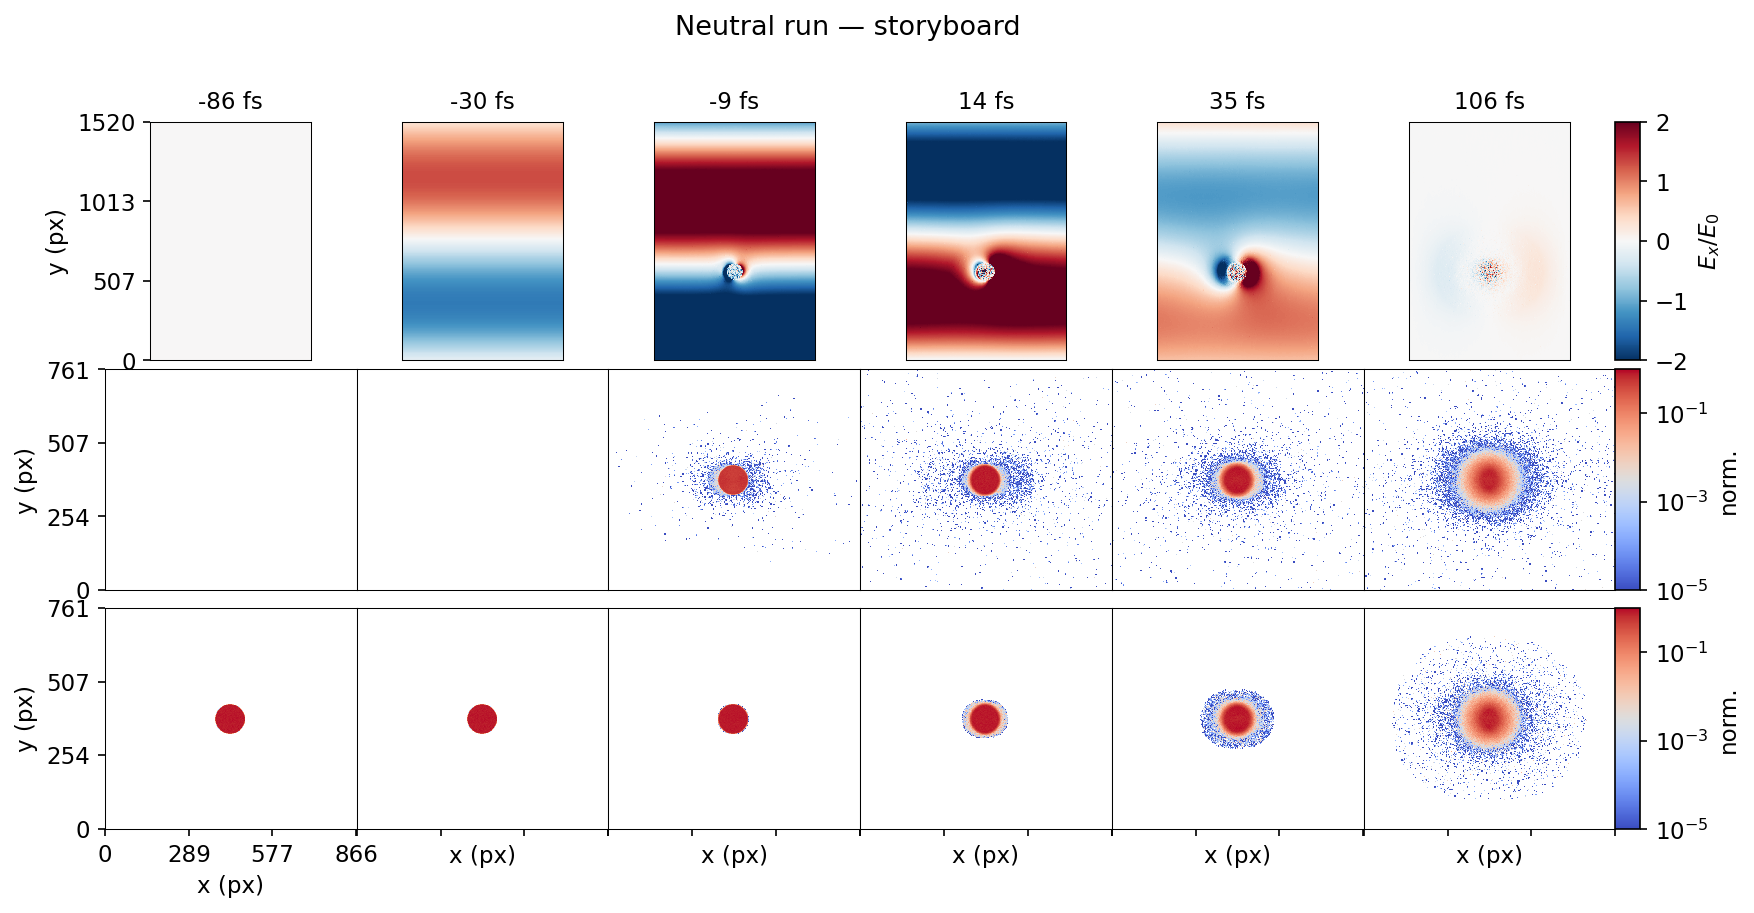

In [8]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
import scipy.constants as sc

# -------- knobs --------
n_frames = 6
I0_Wcm2 = 1e14
field_vlim = 2.0
lognorm_vmin = 1e-5

pad_px_field = 100      # crop padding for field (XY)
pad_px_xz = 100         # crop padding for densities (XZ)

crop_thr_field = 0.5  # threshold on |Ex/E0| for crop (relative to max)
crop_thr_ions  = 1e-3  # threshold on normalized ion density for crop
# ----------------------
def get_pixel_size_nm_from_meta(path):
    """Return (dx_nm, dy_nm, dz_nm) if stored, else None."""
    import h5py
    with h5py.File(path, "r") as f:
        if "meta" not in f:
            return None
        m = f["meta"]
        # flexible names if you add them later
        keys = list(m.keys())
        def read_any(cands):
            for c in cands:
                if c in m:
                    return float(np.array(m[c]))
            return None
        Dx = read_any(["Dx_SI", "cell_width_SI", "dx_SI"])
        Dy = read_any(["Dy_SI", "cell_height_SI", "dy_SI"])
        Dz = read_any(["Dz_SI", "cell_depth_SI", "dz_SI"])
    if Dx is None or Dy is None or Dz is None:
        return None
    return Dx*1e9, Dy*1e9, Dz*1e9  # nm

def set_ticks(ax, shape, dx_nm=None, dy_nm=None, nticks=4, which="x"):
    """Set nice ticks in nm if dx_nm/dy_nm provided, else pixel indices."""
    ny, nx = shape
    if which in ("x", "both"):
        xs = np.linspace(0, nx-1, nticks).round().astype(int)
        ax.set_xticks(xs)
        if dx_nm is not None:
            ax.set_xticklabels([f"{x*dx_nm:.0f}" for x in xs])
            ax.set_xlabel("x (nm)")
        else:
            ax.set_xticklabels([str(x) for x in xs])
            ax.set_xlabel("x (px)")
    if which in ("y", "both"):
        ys = np.linspace(0, ny-1, nticks).round().astype(int)
        ax.set_yticks(ys)
        if dy_nm is not None:
            ax.set_yticklabels([f"{y*dy_nm:.0f}" for y in ys])
            ax.set_ylabel("y (nm)")
        else:
            ax.set_yticklabels([str(y) for y in ys])
            ax.set_ylabel("y (px)")
            
def pick_even(step_keys, n_frames=6):
    step_keys = list(step_keys)
    if len(step_keys) <= n_frames:
        return step_keys
    idx = np.linspace(0, len(step_keys)-1, n_frames).round().astype(int)
    idx = np.unique(idx)
    while len(idx) < n_frames:
        missing = [i for i in range(len(step_keys)) if i not in idx]
        if not missing: break
        idx = np.sort(np.concatenate([idx, [missing[len(missing)//2]]]))
    return [step_keys[i] for i in idx[:n_frames]]

def union_bbox_from_threshold(A_list, thr_rel=1e-3, use_abs=True):
    """
    Build a union bbox over frames where (A / max(A)) > thr_rel.
    Returns (x0,x1,y0,y1) in pixel indices for arrays shaped (Y,X).
    """
    boxes = []
    for A in A_list:
        B = np.abs(A) if use_abs else A
        m = np.nanmax(B) + 1e-300
        Bn = B / m
        idx = np.argwhere(Bn > thr_rel)
        if idx.size == 0:
            continue
        y0, x0 = idx.min(axis=0)
        y1, x1 = idx.max(axis=0)
        boxes.append((x0,x1,y0,y1))
    if not boxes:
        return None
    x0 = min(b[0] for b in boxes)
    x1 = max(b[1] for b in boxes)
    y0 = min(b[2] for b in boxes)
    y1 = max(b[3] for b in boxes)
    return x0,x1,y0,y1

def crop2(A, bbox, pad=20):
    if bbox is None:
        return A
    x0,x1,y0,y1 = bbox
    x0 = max(0, x0-pad); y0 = max(0, y0-pad)
    x1 = min(A.shape[1]-1, x1+pad)
    y1 = min(A.shape[0]-1, y1+pad)
    return A[y0:y1+1, x0:x1+1]

def get_times_for_slices(path, sel_steps):
    all_steps = list_slice_steps(path)
    t = None
    try:
        axes = load_axes(path)
        t = axes.get("time_fs", None)
    except Exception:
        t = None
    if t is not None and len(t) == len(all_steps):
        m = {sk: float(t[i]) for i, sk in enumerate(all_steps)}
        return [m.get(sk, np.nan) for sk in sel_steps]
    return [np.nan]*len(sel_steps)

def plot_storyboard_horizontal_paper(path, title, n_frames=6):
    all_steps = list_slice_steps(path)
    sel_steps = pick_even(all_steps, n_frames=n_frames)
    t_list = get_times_for_slices(path, sel_steps)

    # required datasets
    f0 = available_slice_fields(path, sel_steps[0])
    for need in ("Ex_xy_SI", "rho_e_xz_SI", "rho_i_xz_SI"):
        if need not in f0:
            raise RuntimeError(f"Missing {need} in slices/{sel_steps[0]}: {f0}")

    # load frames
    Ex_list, rhoe_list, rhoi_list = [], [], []
    for sk in sel_steps:
        Ex_list.append(np.squeeze(read_slice(path, sk, "Ex_xy_SI")))      # XY
        rhoe_list.append(np.squeeze(read_slice(path, sk, "rho_e_xz_SI"))) # XZ
        rhoi_list.append(np.squeeze(read_slice(path, sk, "rho_i_xz_SI"))) # XZ

    # normalize E like ana_final: Ex/E0
    E0 = np.sqrt(2.0 * I0_Wcm2 * 1e4 / (sc.c * sc.epsilon_0))
    Exn_list = [A/(E0+1e-300) for A in Ex_list]

    # normalize densities to global max across frames + lognorm
    max_rhoe = np.nanmax([np.nanmax(np.abs(A)) for A in rhoe_list]) + 1e-300
    max_rhoi = np.nanmax([np.nanmax(np.abs(A)) for A in rhoi_list]) + 1e-300
    rhoeN = []
    rhoiN = []
    
    for A in rhoe_list:
        B = np.abs(A) / (max_rhoe + 1e-300)
        B[B <= 0] = np.nan     # mask zeros
        rhoeN.append(B)
    
    for A in rhoi_list:
        B = np.abs(A) / (max_rhoi + 1e-300)
        B[B <= 0] = np.nan     # mask zeros
        rhoiN.append(B)
    
    rho_norm = LogNorm(vmin=lognorm_vmin, vmax=1.0)

    # --------- NEW: separate crop boxes ----------
    # Crop XZ based on ions (good for droplet region)
    bbox_xz = union_bbox_from_threshold(rhoi_list, thr_rel=crop_thr_ions, use_abs=True)

    # Crop XY based on field (where |Ex/E0| is significant)
    bbox_xy = union_bbox_from_threshold(Exn_list, thr_rel=crop_thr_field, use_abs=True)

    # apply crops
    Exn_list = [crop2(A, bbox_xy, pad_px_field) for A in Exn_list]
    rhoeN    = [crop2(A, bbox_xz, pad_px_xz)    for A in rhoeN]
    rhoiN    = [crop2(A, bbox_xz, pad_px_xz)    for A in rhoiN]
    # -------------------------------------------

    # ---- paper-like rcParams ----
    plt.rcParams.update({
        "figure.dpi": 150,
        "savefig.dpi": 300,
        "font.size": 11,
        "axes.titlesize": 11,
        "axes.labelsize": 11,
    })

    # layout: 3 rows + skinny colorbar column
    ncols = len(sel_steps)
    fig = plt.figure(figsize=(2.0*ncols +1.21 , 6.2))
    gs = fig.add_gridspec(
        nrows=3, ncols=ncols+1,
        width_ratios=[1]*ncols + [0.1],
        wspace=0.0, hspace=0.00
    )

    ims_E = []
    ims_e = []
    ims_i = []
    pix = get_pixel_size_nm_from_meta(H5_IONIZED)  # None if not stored
    # For Ex_xy: axes are (y,x) so use dy,dx
    # For rho_xz: axes are (z,x) so use dz,dx
    dx_nm = pix[0] if pix else None
    dy_nm = pix[1] if pix else None
    dz_nm = pix[2] if pix else None

    for j in range(ncols):
        ttl = f"{t_list[j]:.0f} fs" if np.isfinite(t_list[j]) else f"{parse_step(sel_steps[j])}"

        axE  = fig.add_subplot(gs[0, j])
        axNe = fig.add_subplot(gs[1, j])
        axNi = fig.add_subplot(gs[2, j])

        imE = axE.imshow(Exn_list[j], cmap="RdBu_r", origin="lower",
                         interpolation="nearest", vmin=-field_vlim, vmax=field_vlim,
                         aspect="equal")
        imNe = axNe.imshow(rhoeN[j], cmap="coolwarm", origin="lower",
                           interpolation="nearest", norm=rho_norm, aspect="equal")
        imNi = axNi.imshow(rhoiN[j], cmap="coolwarm", origin="lower",
                           interpolation="nearest", norm=rho_norm, aspect="equal")

        ims_E.append(imE); ims_e.append(imNe); ims_i.append(imNi)
  
        for ax in (axE, axNe, axNi):
            ax.set_xticks([]); ax.set_yticks([])
            for sp in ax.spines.values():
                sp.set_visible(True)
                sp.set_linewidth(0.5)
                sp.set_color("black")

        axE.set_title(ttl)

        if j == 0:
            axE.set_ylabel(r"$E_x/E_0$")
            axNe.set_ylabel(r"$|\rho_e|$")
            axNi.set_ylabel(r"$|\rho_i|$")
        # inside: for j in range(ncols):
        
        # show y ticks only on first column
        if j == 0:
            set_ticks(axE,  Exn_list[j].shape, dx_nm=dx_nm, dy_nm=dy_nm, which="y")
            set_ticks(axNe, rhoeN[j].shape,    dx_nm=dx_nm, dy_nm=dz_nm, which="y")  # z-axis
            set_ticks(axNi, rhoiN[j].shape,    dx_nm=dx_nm, dy_nm=dz_nm, which="y")  # z-axis
        # bottom-row x tick labels: only keep on first column (j==0)
        if j != 0:
            axNi.tick_params(labelbottom=False)   # hides the numbers, keeps tick marks
        # show x ticks only on bottom row — do it for ALL columns (or just leftmost if you prefer)
        set_ticks(axNi, rhoiN[j].shape, dx_nm=dx_nm, dy_nm=dz_nm, which="x")

    # shared colorbars (one per row) in last column
    caxE  = fig.add_subplot(gs[0, -1])
    caxe  = fig.add_subplot(gs[1, -1])
    caxi  = fig.add_subplot(gs[2, -1])

    cbE = fig.colorbar(ims_E[-1], cax=caxE)
    cbe = fig.colorbar(ims_e[-1], cax=caxe)
    cbi = fig.colorbar(ims_i[-1], cax=caxi)
    cbE = fig.colorbar(ims_E[-1], cax=caxE)
    cbe = fig.colorbar(ims_e[-1], cax=caxe)
    cbi = fig.colorbar(ims_i[-1], cax=caxi)
    # --- match colorbar height to the corresponding row axes height ---
    # pick any axis from that row (I use last column axis from each row)
    bboxE  = axE.get_position()   # last created axE in the loop is last column
    bboxNe = axNe.get_position()
    bboxNi = axNi.get_position()
    
    for cax, bbox in [(caxE, bboxE), (caxe, bboxNe), (caxi, bboxNi)]:
        p = cax.get_position()
        cax.set_position([p.x0, bbox.y0, p.width, bbox.height])
        
    cbE.set_label(r"$E_x/E_0$")
    cbe.set_label("norm.")
    cbi.set_label("norm.")

    fig.suptitle(title, y=0.995, fontsize=13)
  
    plt.show()
# Run
#plot_storyboard_horizontal_paper(H5_IONIZED, "Pre-ionized run — storyboard", n_frames=n_frames)
plot_storyboard_horizontal_paper(H5_NEUTRAL, "Neutral run — storyboard", n_frames=n_frames)

# Figure 2 — Ignition + collective dynamics (timeseries + radial)

Panels you can do from reduced H5:

- $N_e(t)$ and $dN_e/dt$ (electron yield / avalanche signature)
- Ion charge state: $\langle Z \rangle(t)$ and charge fractions
- Expansion: $\langle r \rangle(t)$ and/or $R_{99}(t)$ from ion radial distribution
- Net charge inside droplet vs time (approximate, see notes)



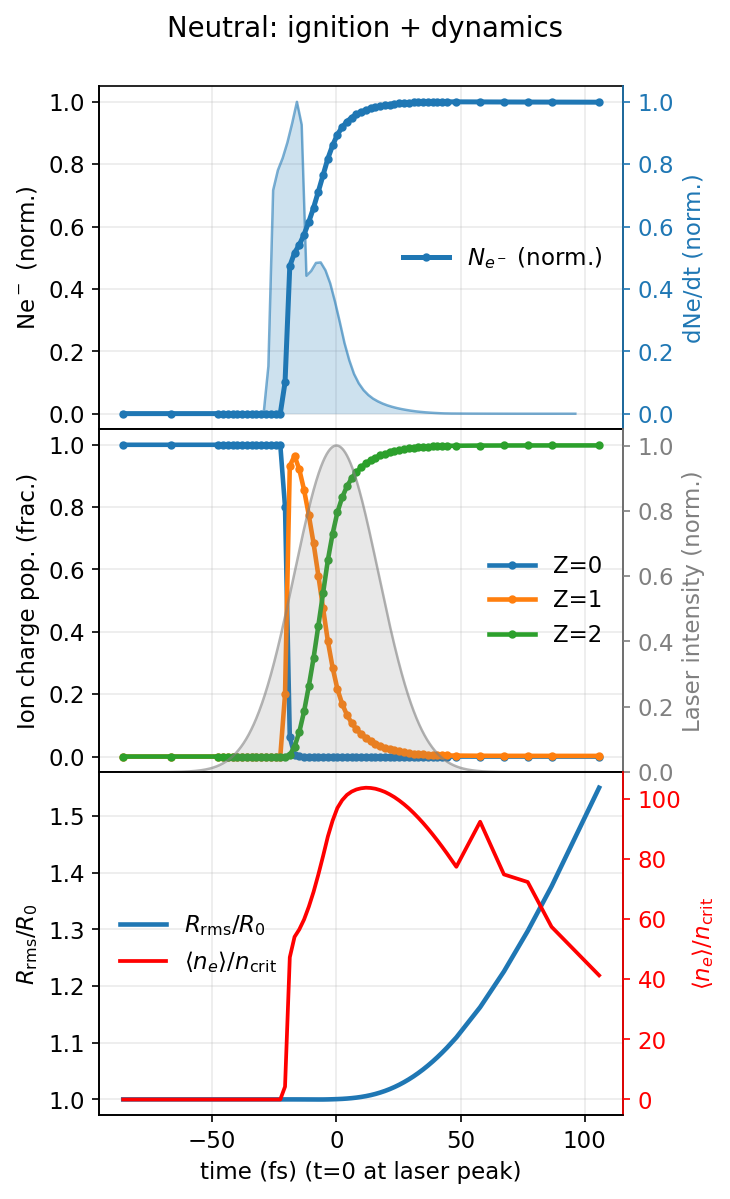

In [4]:
import numpy as np
import matplotlib.pyplot as plt

# ---------- user knobs ----------
TAU_FWHM_FS = 40.0          # laser intensity FWHM (fs)
NORM_RATE_SMOOTH = 7        # odd integer window for simple moving-average smoothing of dNe/dt
SHOW_Z = (0, 1, 2)          # Z lines to show in middle panel
# -------------------------------

def movavg(y, w):
    w = int(w)
    if w < 3 or w % 2 == 0:
        return y
    k = w // 2
    ypad = np.pad(y, (k, k), mode="edge")
    return np.convolve(ypad, np.ones(w)/w, mode="valid")

def gaussian_envelope(t_fs, fwhm_fs):
    # normalized intensity envelope, peak at t=0
    return np.exp(-4*np.log(2) * (t_fs / fwhm_fs)**2)

def ddt_midpoints(t_fs, y):
    t = np.asarray(t_fs)
    y = np.asarray(y)
    dt = np.diff(t)
    dy = np.diff(y)
    tmid = 0.5*(t[1:] + t[:-1])
    return tmid, dy/(dt + 1e-300)

def plot_figure2_ignition(path, title):
    axes = load_axes(path)
    ts = load_timeseries(path)
    rd = load_radial(path)

    t = axes["time_fs"]

    # ---------- TOP: electron population (normalized) + creation rate (background) ----------
    if "He_e_N_real" in ts:
        Ne = ts["He_e_N_real"].astype(float)
    else:
        Ne = ts["He_e_N_macro"].astype(float)

    Ne_norm = Ne / (np.nanmax(Ne) + 1e-300)
    tmid, dNe_dt = ddt_midpoints(t, Ne_norm)
    dNe_dt = movavg(dNe_dt, NORM_RATE_SMOOTH)
    # normalize rate for a nice filled background
    dNe_dt_norm = dNe_dt / (np.nanmax(np.abs(dNe_dt)) + 1e-300)

    # ---------- MIDDLE: ion charge populations Z=0,1,2 (normalized) + laser envelope background ----------
    if "He_i_charge_frac" not in ts:
        raise RuntimeError("Missing timeseries/He_i_charge_frac in reduced H5. "
                           "You need this for Z=0/1/2 ionization evolution.")
    fracZ = ts["He_i_charge_frac"]  # expected shape (Nt, Zmax+1)
    if fracZ.ndim != 2:
        raise RuntimeError(f"Unexpected He_i_charge_frac shape: {fracZ.shape}")

    # ensure rows correspond to time
    if fracZ.shape[0] != len(t) and fracZ.shape[1] == len(t):
        fracZ = fracZ.T

    # ---------- BOTTOM: ion expansion R99/R0 ----------
    r_mid = axes["r_mid_m"]
    n_r = rd["He_i_n_r"]
    # orient (Nt, Nr)
    if n_r.shape[0] == len(t) and n_r.shape[1] == len(r_mid):
        n_t_r = n_r
    elif n_r.shape[1] == len(t) and n_r.shape[0] == len(r_mid):
        n_t_r = n_r.T
    else:
        raise RuntimeError(f"He_i_n_r shape {n_r.shape} does not match (Nt,Nr)=({len(t)},{len(r_mid)})")

    n_t_r = np.maximum(n_t_r, 0.0)
    cdf = np.cumsum(n_t_r, axis=1)
    tot = cdf[:, -1] + 1e-300
    frac = cdf / tot[:, None]
    R99 = np.array([r_mid[min(np.searchsorted(frac[i], 0.99), len(r_mid)-1)] for i in range(len(t))])
    R0 = R99[0] if R99[0] > 0 else (np.nanmax(R99) + 1e-300)
    R99_over_R0 = R99 / (R0 + 1e-300)

    # ---------- figure styling ----------
    plt.rcParams.update({
        "figure.dpi": 150,
        "savefig.dpi": 300,
        "font.size": 11,
        "axes.titlesize": 12,
        "axes.labelsize": 11,
    })

    fig, ax = plt.subplots(3, 1, figsize=(5,8), sharex=True,
                           gridspec_kw={"hspace": 0.0})

    # ---- TOP panel ----
     # Electron population (left axis)
    Ne_line = ax[0].plot(t, Ne_norm, ".-",lw=2.4, label=r"$N_{e^-}$ (norm.)")
    color_Ne = Ne_line[0].get_color()

    ax[0].set_ylabel(f"Ne$^-$ (norm.)")
    ax[0].set_ylim(-0.05, 1.05)
    ax[0].grid(True, alpha=0.25)

    # Electron creation rate (right axis)
    ax_rate = ax[0].twinx()
    # normalize rate independently for visual clarity
    dNe_dt_norm2 = dNe_dt / (np.nanmax(np.abs(dNe_dt)) + 1e-300)
    ax_rate.fill_between(tmid,dNe_dt_norm2,0,color=color_Ne,alpha=0.22,lw=0,label="dNe/dt (norm.)"    )
    ax_rate.plot(tmid,dNe_dt_norm2,color=color_Ne,alpha=0.6,lw=1.2)
    ax_rate.set_ylabel("dNe/dt (norm.)", color=color_Ne)
    ax_rate.tick_params(axis="y", colors=color_Ne)
    ax_rate.spines["right"].set_color(color_Ne)
    ax_rate.set_ylim(-0.05, 1.05)
    # cleaner look
    ax_rate.spines["top"].set_visible(False)
    ax[0].legend(loc="center right",frameon=False)   
    
    # ---- MIDDLE panel ----
    # Ion charge populations on left axis
    for Z in SHOW_Z:
        if Z < fracZ.shape[1]:
            ax[1].plot(t, fracZ[:, Z], ".-", lw=2.2, label=f"Z={Z}")

    ax[1].set_ylabel("Ion charge pop. (frac.)")
    ax[1].set_ylim(-0.05, 1.05)
    ax[1].grid(True, alpha=0.25)

    # Laser envelope on right axis
    ax_laser = ax[1].twinx()
    laser_color="gray"
    
        # Laser envelope on a dense time grid (smooth)
    t_dense = np.linspace(np.nanmin(t), np.nanmax(t), 1500)
    Ienv_dense = gaussian_envelope(t_dense, TAU_FWHM_FS)
    Ienv_dense /= (np.max(Ienv_dense) + 1e-300)
    
    ax_laser.fill_between(t_dense, Ienv_dense, 0, color="gray", alpha=0.18, lw=0, label="Laser envelope")
    ax_laser.plot(t_dense, Ienv_dense, color="gray", alpha=0.6, lw=1.2)
    ax_laser.set_ylim(0, 1.05)
    ax_laser.set_ylabel("Laser intensity (norm.)",color=laser_color)
    # color right axis ticks + spine
    ax_laser.tick_params(axis="y", colors=laser_color)
    ax_laser.spines["right"].set_color(laser_color)
    # cleaner look
    ax_laser.spines["top"].set_visible(False)
    ax[1].legend(loc="center right", frameon=False)
    
    # ---- BOTTOM panel: R_rms/R0 (ions) + <n_e>/ncrit (inside R_rms) ----
    LAMBDA_NM = 800.0  # set to your laser wavelength
    
    def orient_to_t_r(A, Nt, Nr):
        A = np.asarray(A)
        if A.shape == (Nt, Nr):
            return A
        if A.shape == (Nr, Nt):
            return A.T
        raise RuntimeError(f"Expected (Nt,Nr)=({Nt},{Nr}) or (Nr,Nt), got {A.shape}")
    
    Nr = len(r_mid)
    Nt = len(t)
    
    n_i_t_r = orient_to_t_r(rd["He_i_n_r"], Nt, Nr)
    n_e_t_r = orient_to_t_r(rd["He_e_n_r"], Nt, Nr)
    
    n_i_t_r = np.maximum(n_i_t_r, 0.0)
    n_e_t_r = np.maximum(n_e_t_r, 0.0)
    
    # --- Ion rms radius ---
    Ni = np.sum(n_i_t_r, axis=1) + 1e-300
    r2_mean = np.sum(n_i_t_r * (r_mid[None, :]**2), axis=1) / Ni
    Rrms = np.sqrt(np.maximum(r2_mean, 0.0))
    
    R0 = Rrms[0] if Rrms[0] > 0 else (np.nanmax(Rrms) + 1e-300)
    Rrms_over_R0 = Rrms / (R0 + 1e-300)
    
    # --- Electron mean density inside Rrms ---
    # electrons inside Rrms: sum shells with r_mid <= Rrms(t)
    Ne_in = np.zeros(Nt)
    for i in range(Nt):
        mask = r_mid <= Rrms[i]
        Ne_in[i] = np.sum(n_e_t_r[i, mask])
    
    V_sphere = (4.0/3.0) * np.pi * (Rrms**3 + 1e-300)
    ne_mean = Ne_in / V_sphere  # 1/m^3
    
    # --- Critical density ---
    lam_m = LAMBDA_NM * 1e-9
    omega = 2.0*np.pi*sc.c/lam_m
    ncrit = sc.epsilon_0 * sc.m_e * omega**2 / sc.e**2  # 1/m^3
    
    ne_over_ncrit = ne_mean / (ncrit + 1e-300)
    
    # Plot left axis: radius
    ax[2].plot(t, Rrms_over_R0, lw=2.2, label=r"$R_{\rm rms}/R_0$")
    ax[2].set_ylabel(r"$R_{\rm rms}/R_0$")
    ax[2].grid(True, alpha=0.25)
    
    # Plot right axis: density in units of ncrit
    ax_den = ax[2].twinx()
    den_color = "red"
    ax_den.plot(t, ne_over_ncrit, lw=1.8, color=den_color, label=r"$\langle n_e\rangle/n_{\rm crit}$")
    #ax_den.set_yscale("log")
    ax_den.set_ylabel(r"$\langle n_e\rangle/n_{\rm crit}$", color=den_color)
    ax_den.tick_params(axis="y", colors=den_color)
    ax_den.spines["right"].set_color(den_color)
    ax_den.spines["top"].set_visible(False)
    ax[2].set_xlabel("time (fs) (t=0 at laser peak)")
    
    # Combined legend (bottom)
    ax[2].legend(
        [ax[2].lines[-1], ax_den.lines[-1]],
        [r"$R_{\rm rms}/R_0$", r"$\langle n_e\rangle/n_{\rm crit}$"],
        loc="center left",
        frameon=False
    )
    fig.suptitle(title, y=0.995)
    plt.tight_layout()
    plt.show()

# Run both cases
plot_figure2_ignition(H5_NEUTRAL, "Neutral: ignition + dynamics")

In [5]:
plot_ignition_dynamics

NameError: name 'plot_ignition_dynamics' is not defined

# Figure 3 — Angular anisotropy / asymmetry vs time (from dN/dμ)

From your reduced H5 you can compute a clean **forward-backward asymmetry** along the chosen axis from the stored `He_e_dNdmu(t,μ)`.

Define:
- forward = μ>0
- backward = μ<0
- $A(t) = (N_+ - N_-)/(N_+ + N_-)$

This is a strong “collective” diagnostic without needing raw momenta.

**Note:** the *phase-shift* analysis (dipole vs laser E) is not possible unless you export a dipole moment time series.


In [6]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm

def asymmetry_from_dNdmu(mu_mid, dNdmu_t_mu):
    H = np.asarray(dNdmu_t_mu)
    if H.shape[1] == len(mu_mid):
        Ht = H
    elif H.shape[0] == len(mu_mid):
        Ht = H.T
    else:
        raise ValueError("dNdmu shape doesn't match mu_mid.")
    mu = np.asarray(mu_mid)
    plus = mu > 0
    minus = mu < 0
    Np = np.sum(Ht[:, plus], axis=1)
    Nm = np.sum(Ht[:, minus], axis=1)
    return (Np - Nm) / (Np + Nm + 1e-300)

def _orient_mu_t(dNdmu, mu):
    H = np.asarray(dNdmu)
    # return (Nmu, Nt) for imshow with extent [tmin,tmax, mumin,mumax]
    if H.shape[0] == len(mu):
        return H
    if H.shape[1] == len(mu):
        return H.T
    raise ValueError(f"Cannot orient dNdmu with shape {H.shape} to mu length {len(mu)}")

def plot_mu_heatmap_and_asym(path, label, t_range_fs=None, vmin_mode="percentile", p_lo=0.5, p_hi=99.5):
    axes = load_axes(path)
    sp = load_spectra(path)
    t = np.asarray(axes["time_fs"])
    mu = np.asarray(axes["mu_mid"])
    dNdmu = sp["He_e_dNdmu"]

    # --- NEW: time window mask ---
    if t_range_fs is not None:
        tmin, tmax = t_range_fs
        mask_t = (t >= tmin) & (t <= tmax)
        if not np.any(mask_t):
            raise RuntimeError(f"No points in requested t_range_fs={t_range_fs}.")
        t = t[mask_t]
        dNdmu = np.asarray(dNdmu)[mask_t, :] if np.asarray(dNdmu).shape[0] == len(axes["time_fs"]) else np.asarray(dNdmu)[:, mask_t]
    # -----------------------------

    Hmu_t = _orient_mu_t(dNdmu, mu)   # (Nmu, Nt) AFTER slicing
    Ht_mu = Hmu_t.T
    A = asymmetry_from_dNdmu(mu, Ht_mu)

    Hplot = np.array(Hmu_t, dtype=float)
    Hplot[Hplot <= 0] = np.nan

    finite = Hplot[np.isfinite(Hplot)]
    if finite.size == 0:
        raise RuntimeError("All heatmap values are zero/NaN after masking.")

    if vmin_mode == "percentile":
        vmin = np.percentile(finite, p_lo)
        vmax = np.percentile(finite, p_hi)
    else:
        vmin = np.nanmin(finite)
        vmax = np.nanmax(finite)

    vmin = max(vmin, 1e-1)
    vmax = max(vmax, vmin * 10)

    fig = plt.figure(figsize=(7.2, 3.4), constrained_layout=False)
    gs = fig.add_gridspec(2, 2, width_ratios=[1.0, 0.05], height_ratios=[3, 1], wspace=0.01, hspace=0.08)

    ax0 = fig.add_subplot(gs[0, 0])
    ax1 = fig.add_subplot(gs[1, 0], sharex=ax0)
    cax = fig.add_subplot(gs[0, 1])

    im = ax0.imshow(
        Hplot,
        origin="lower",
        aspect="auto",
        extent=[t.min(), t.max(), mu.min(), mu.max()],
        cmap="viridis",
        norm=LogNorm(vmin=vmin, vmax=vmax),
        #interpolation="nearest",
    )
    cb = fig.colorbar(im, cax=cax)
    cb.set_label(r"$dN/d\mu$ (arb.)")

    ax0.set_ylabel(r"$\mu = \cos\theta$")
    ax0.set_title(f"{label}: electron angular distribution vs time")
    plt.setp(ax0.get_xticklabels(), visible=False)

    ax1.plot(t, A, lw=2.0)
    ax1.axhline(0, lw=1.0)
    ax1.set_ylabel("A(t)")
    ax1.set_xlabel("time (fs)")
    ax1.grid(True, alpha=0.25)

    plt.show()

# Run
plot_mu_heatmap_and_asym(H5_IONIZED, "Pre-ionized", t_range_fs=(-80, 40))
plot_mu_heatmap_and_asym(H5_NEUTRAL, "Neutral", t_range_fs=(-27, 25))

NameError: name 'H5_IONIZED' is not defined

# Figure 4 — Spectral fingerprints (heatmaps)

From `/spectra` + `/axes` you can do:
- Electron spectra heatmap: `He_e_dNdE(t,E)`
- Ion spectra heatmap: `He_i_dNdE(t,E)`
- Optional: overlay a few lineouts at key times


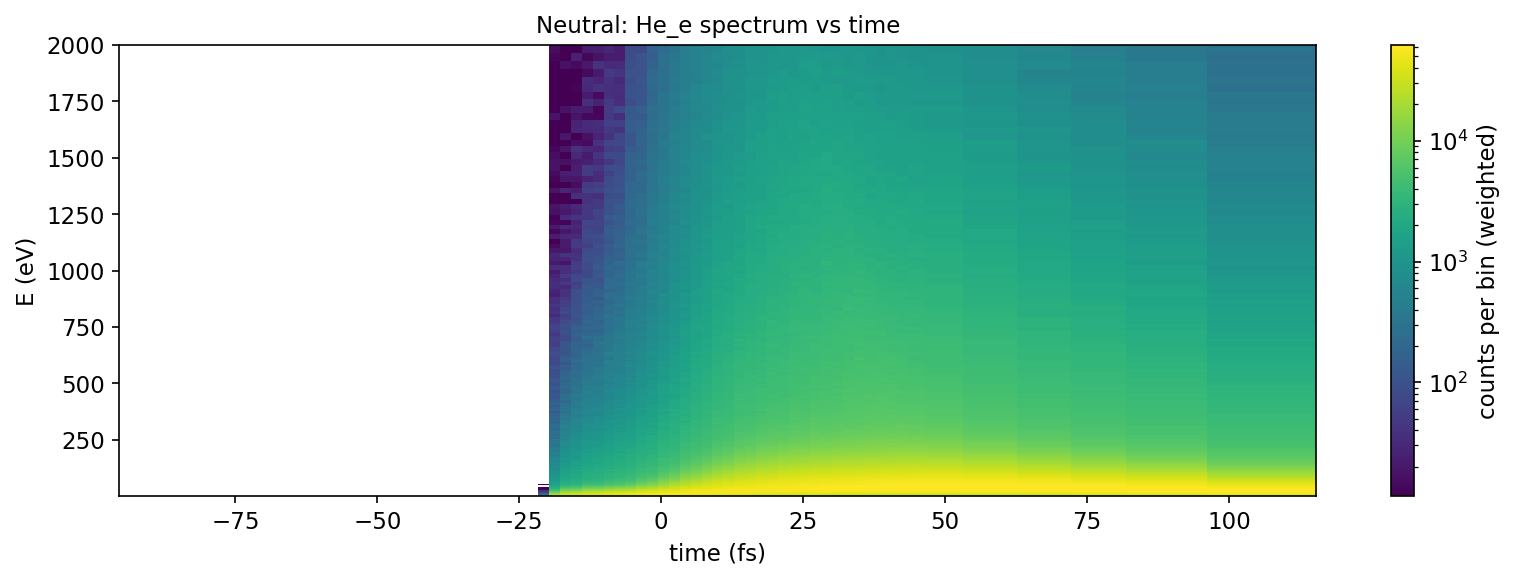

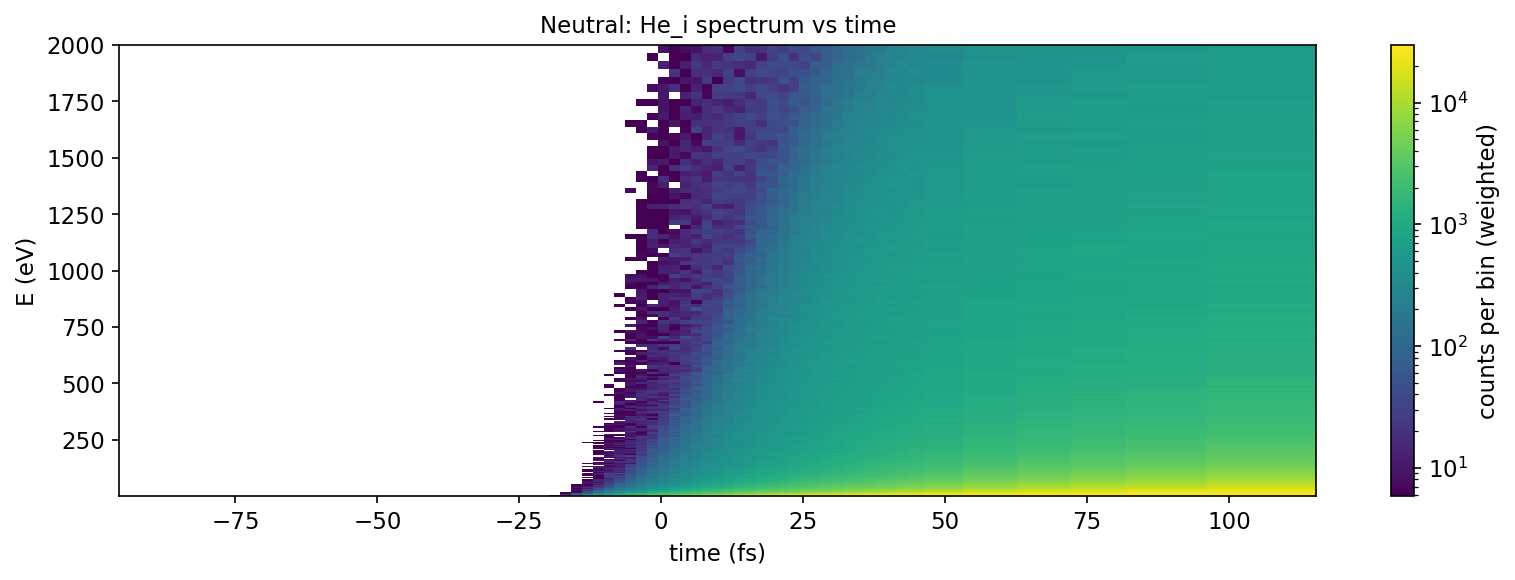

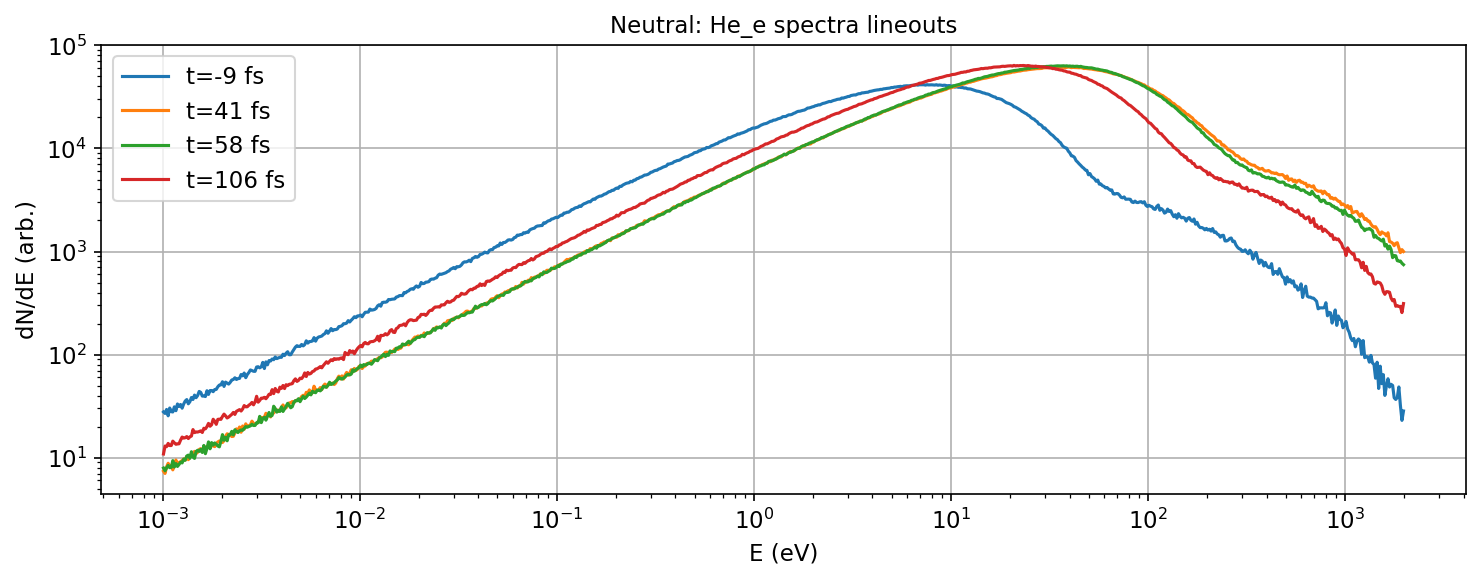

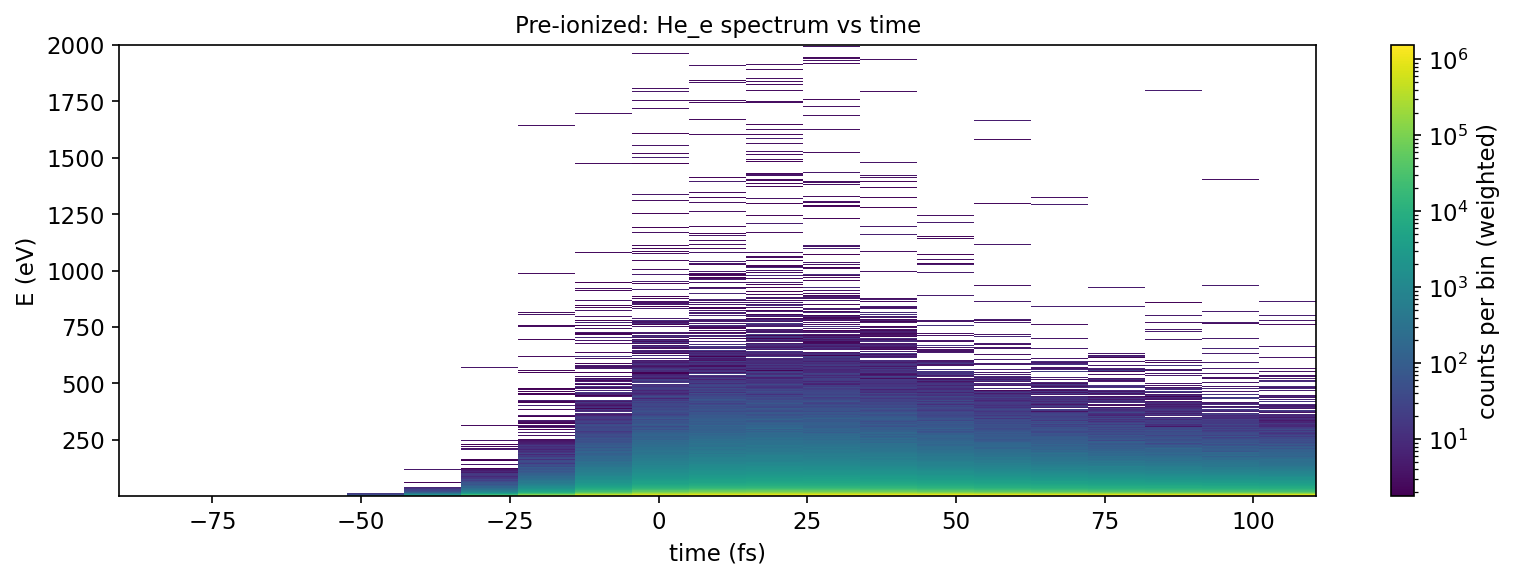

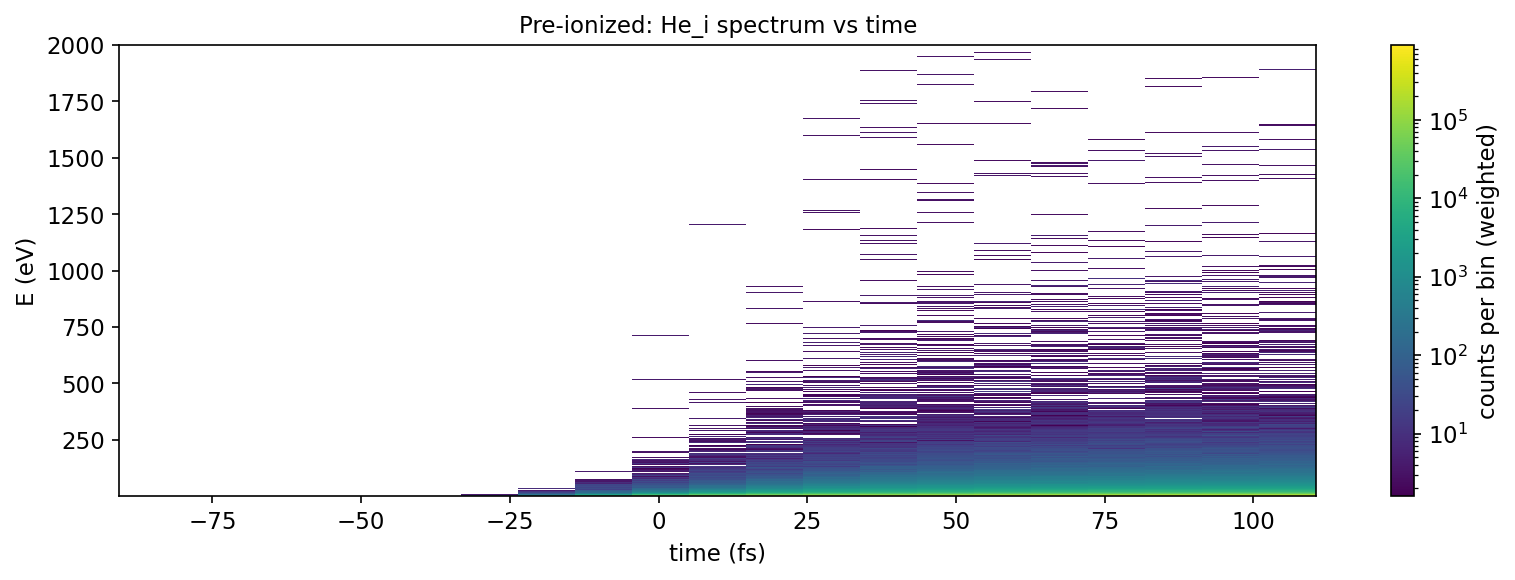

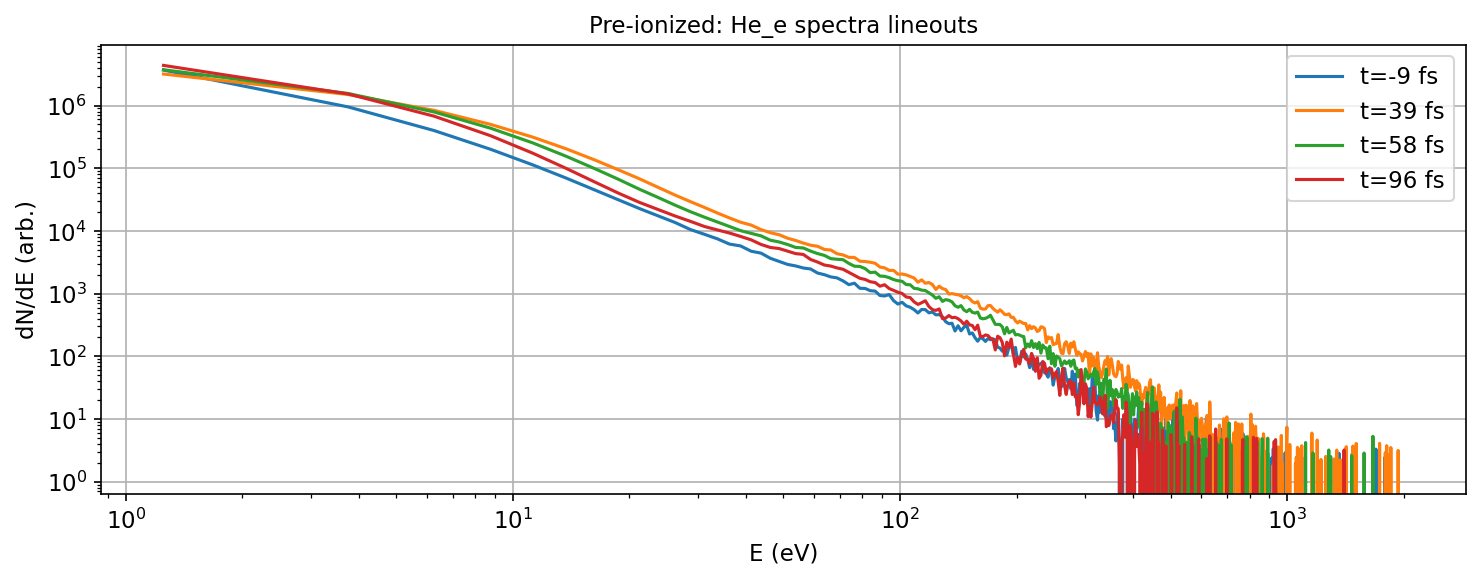

In [9]:
from matplotlib.colors import LogNorm

def plot_spectrum_heatmap(path, label, species="He_e", t_range_fs=None, vmin_p=1.0, vmax_p=99.5):
    axes = load_axes(path)
    sp = load_spectra(path)

    t = np.asarray(axes["time_fs"])
    E_edges = np.asarray(axes["E_edges_eV"])      # IMPORTANT: use edges, not mid
    E_mid   = np.asarray(axes["E_mid_eV"])

    H = np.asarray(sp[f"{species}_dNdE"])         # counts per bin (weighted)

    # ensure HtE is (Nt, NE)
    if H.shape[0] == len(t):
        HtE = H
    else:
        HtE = H.T

    # optional time window
    if t_range_fs is not None:
        tmin, tmax = t_range_fs
        m = (t >= tmin) & (t <= tmax)
        t = t[m]
        HtE = HtE[m, :]

    # mask zeros for LogNorm
    Hplot = HtE.astype(float)
    Hplot[Hplot <= 0] = np.nan
    finite = Hplot[np.isfinite(Hplot)]
    if finite.size == 0:
        raise RuntimeError("All entries are zero/NaN.")

    vmin = np.percentile(finite, vmin_p)
    vmax = np.percentile(finite, vmax_p)
    vmin = max(vmin, 1e-3)
    vmax = max(vmax, vmin * 10)

    # build time edges (uniform in time is fine)
    t_edges = np.concatenate([0.5*(t[1:]+t[:-1]), [t[-1] + (t[-1]-t[-2])/2]])
    t_edges = np.concatenate([[t[0] - (t[1]-t[0])/2], t_edges])

    plt.figure(figsize=(11,4))
    im = plt.pcolormesh(
        t_edges, E_edges, Hplot.T,   # NOTE transpose: (NE, Nt)
        norm=LogNorm(vmin=vmin, vmax=vmax),
        shading="auto",
        cmap="viridis"
    )
    plt.colorbar(im, label="counts per bin (weighted)")
    plt.xlabel("time (fs)")
    plt.ylabel("E (eV)")
    #plt.xscale("log")   # since bins are log-ish, show log y-axis
    #plt.yscale("log")   # since bins are log-ish, show log y-axis
    plt.title(f"{label}: {species} spectrum vs time")
    plt.tight_layout()
    plt.show()

def plot_lineouts(path, label, species="He_e", times_fs=(0, 50, 200)):
    axes = load_axes(path)
    sp = load_spectra(path)
    t = axes["time_fs"]
    E = axes["E_mid_eV"]
    H = sp[f"{species}_dNdE"]
    # make (Nt,NE)
    if H.shape[1] == len(E):
        HtE = H
    else:
        HtE = H.T

    plt.figure(figsize=(10,4))
    for tt in times_fs:
        i = int(np.argmin(np.abs(t-tt)))
        plt.plot(E, HtE[i], label=f"t={t[i]:.0f} fs")
    plt.xlabel("E (eV)")
    plt.ylabel("dN/dE (arb.)")
    plt.title(f"{label}: {species} spectra lineouts")
    plt.grid(True)
    plt.yscale("log")
    plt.xscale("log")
    plt.legend()
    plt.tight_layout()
    plt.show()

for p,label in [(H5_NEUTRAL,"Neutral"), (H5_IONIZED,"Pre-ionized")]:
    plot_spectrum_heatmap(p, label, "He_e")
    plot_spectrum_heatmap(p, label, "He_i")
    plot_lineouts(p, label, "He_e", times_fs=(-10, 40, 60, 100))


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm

def plot_combined_spectrum(
    path,
    label,
    t_range_fs=None,
    ylim_eV=None,
    yscale="linear",   # "linear" or "symlog"
    p_lo=1,
    p_hi=99.5
):

    axes = load_axes(path)
    sp = load_spectra(path)

    t = np.asarray(axes["time_fs"])
    E = np.asarray(axes["E_mid_eV"])

    H_e = np.asarray(sp["He_e_dNdE"])
    H_i = np.asarray(sp["He_i_dNdE"])

    # ensure (Nt,NE)
    HtE_e = H_e if H_e.shape[0] == len(t) else H_e.T
    HtE_i = H_i if H_i.shape[0] == len(t) else H_i.T

    # optional time window
    if t_range_fs is not None:
        tmin,tmax = t_range_fs
        m = (t>=tmin)&(t<=tmax)
        t = t[m]
        HtE_e = HtE_e[m,:]
        HtE_i = HtE_i[m,:]

    # electrons negative energy
    H_e_plot = np.flip(HtE_e,axis=1)
    H_i_plot = HtE_i

    H_combined = np.concatenate([H_e_plot,H_i_plot],axis=1)

    E_neg = -E[::-1]
    E_pos = E
    E_comb = np.concatenate([E_neg,E_pos])

    H_plot = H_combined.T.astype(float)
    H_plot[H_plot<=0] = np.nan

    finite = H_plot[np.isfinite(H_plot)]
    vmin = np.percentile(finite,p_lo)
    vmax = np.percentile(finite,p_hi)

    fig,ax = plt.subplots(figsize=(8,4))

    im = ax.imshow(
        H_plot,
        origin="lower",
        aspect="auto",
        extent=[t.min(),t.max(),E_comb.min(),E_comb.max()],
        cmap="viridis",
        norm=LogNorm(vmin=max(vmin,1e-3),vmax=vmax),
        interpolation="nearest"
    )

    ax.axhline(0,color="k",lw=1)

    # energy scaling
    if yscale == "symlog":
        ax.set_yscale("symlog",linthresh=1)

    # energy limits
    if ylim_eV is not None:
        ax.set_ylim(ylim_eV)

    ax.set_xlabel("time (fs)")
    ax.set_ylabel("Energy (eV)")
    ax.set_title(label)

    cbar = plt.colorbar(im,ax=ax)
    cbar.set_label("counts per bin (weighted)")

    ax.text(t.min()+0.02*(t.max()-t.min()),-0.8*np.max(E),"electrons",color="white")
    ax.text(t.min()+0.02*(t.max()-t.min()),0.7*np.max(E),"ions",color="white")

    plt.tight_layout()
    plt.show()

In [ ]:
plot_combined_spectrum(H5_IONIZED,"Pre-ionized",t_range_fs=(-60,125))


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
import scipy.constants as sc
import adios2
import glob, os

import re, glob, os

def list_bp5_sorted_by_step(openpmd_dir):
    files = glob.glob(os.path.join(openpmd_dir, "*.bp5"))
    pairs = []
    for fp in files:
        name = os.path.basename(fp)
        m = re.search(r"(\d+)\.bp5$", name)   # robust: last digits before .bp5
        if not m:
            continue
        step = int(m.group(1))
        pairs.append((step, fp))
    if not pairs:
        raise RuntimeError(f"No step-numbered .bp5 files found in {openpmd_dir}")
    pairs.sort(key=lambda x: x[0])
    return pairs
    
def _fast_weighted_hist(E_eV, w, edges):
    nb = len(edges) - 1
    idx = np.searchsorted(edges, E_eV, side="right") - 1
    m = (idx >= 0) & (idx < nb) & np.isfinite(E_eV) & np.isfinite(w)
    if not np.any(m):
        return np.zeros(nb, dtype=np.float64)
    return np.bincount(idx[m], weights=w[m], minlength=nb).astype(np.float64)

def _load_dt_fs_and_unit_time(first_bp5):
    # mirrors NanoPlasmaRun._load_meta() logic
    step0 = int(os.path.basename(first_bp5).split("_")[-1].split(".")[0])
    with adios2.Stream(first_bp5, "r") as f:
        for _ in f.steps():
            unit_time_SI = float(f.read_attribute(f"/data/{step0}/unit_time"))
            dt_code      = float(f.read_attribute(f"/data/{step0}/dt"))
            dt_fs        = (dt_code * unit_time_SI) * 1e15
    return dt_fs

def _try_read_momentum_weight_SI(f, step, species):
    """
    Returns (px_SI, py_SI, pz_SI, w) or None if species datasets are missing.
    """
    base = f"/data/{step}/particles/{species}"

    # quick existence check (fast) using available variables
    av = f.available_variables()
    need = [
        f"{base}/momentum/x",
        f"{base}/momentum/y",
        f"{base}/momentum/z",
        f"{base}/weighting",
    ]
    if any(k not in av for k in need):
        return None

    # read arrays
    px = f.read(need[0]).astype(np.float64)
    py = f.read(need[1]).astype(np.float64)
    pz = f.read(need[2]).astype(np.float64)
    w  = f.read(need[3]).astype(np.float64)

    # empty species is OK → return empty arrays (caller will handle)
    try:
        unit_p = float(f.read_attribute(f"{base}/momentum/x/unitSI"))
    except Exception:
        unit_p = 1.0

    return px*unit_p, py*unit_p, pz*unit_p, w
    
def plot_combined_spectrum_from_raw_fast(
    openpmd_dir,
    label,
    laser_peak_at_target,          # IMPORTANT for t=0 at laser peak
    species_e="He_e",
    species_i="He_i",
    ion_mass_kg=4.0*sc.atomic_mass,
    bins=320,
    Emax=250.0,
    t_range_fs=None,
    ylim_eV=None,
    yscale="linear",               # "linear" or "symlog"
    p_lo=1.0,
    p_hi=99.5,
    max_files=None,
):
    files = sorted(glob.glob(os.path.join(openpmd_dir, "*.bp5")))
    if not files:
        raise FileNotFoundError(f"No .bp5 files found in: {openpmd_dir}")
    if max_files is not None:
        files = files[:max_files]

    dt_fs = _load_dt_fs_and_unit_time(files[0])

    E_edges = np.linspace(0.0, float(Emax), int(bins) + 1)
    E_mid   = 0.5*(E_edges[1:] + E_edges[:-1])

    t_fs_list = []
    He_list, Hi_list = [], []

    # for sanity / clipping diagnostics
    e_max_seen = 0.0
    i_max_seen = 0.0
    pairs = list_bp5_sorted_by_step(openpmd_dir)
    if max_files is not None:
        pairs = pairs[:max_files]

    for step, bp in pairs:
        t_fs = (step - laser_peak_at_target) * dt_fs
        t_fs_list.append(t_fs)

        with adios2.Stream(bp, "r") as f:
            for _ in f.steps():
                # electrons
                data = _try_read_momentum_weight_SI(f, step, species_e)
                if data is None:
                    he = np.zeros(len(E_edges)-1, dtype=np.float64)
                else:
                    pxe, pye, pze, we = data
                    if pxe.size == 0:
                        he = np.zeros(len(E_edges)-1, dtype=np.float64)
                    else:
                        Ee = (pxe*pxe + pye*pye + pze*pze) / (2.0*sc.m_e) / sc.e
                        he = _fast_weighted_hist(Ee, we, E_edges)
                He_list.append(he)
                
                # ions
                data = _try_read_momentum_weight_SI(f, step, species_i)
                if data is None:
                    hi = np.zeros(len(E_edges)-1, dtype=np.float64)
                else:
                    pxi, pyi, pzi, wi = data
                    if pxi.size == 0:
                        hi = np.zeros(len(E_edges)-1, dtype=np.float64)
                    else:
                        Ei = (pxi*pxi + pyi*pyi + pzi*pzi) / (2.0*ion_mass_kg) / sc.e
                        hi = _fast_weighted_hist(Ei, wi, E_edges)
                Hi_list.append(hi)

    t = np.asarray(t_fs_list)
    HtE_e = np.vstack(He_list)  # (Nt, NE)
    HtE_i = np.vstack(Hi_list)

    # optional time window
    if t_range_fs is not None:
        tmin, tmax = t_range_fs
        m = (t >= tmin) & (t <= tmax)
        t = t[m]
        HtE_e = HtE_e[m, :]
        HtE_i = HtE_i[m, :]

    # electrons negative energy
    H_e_plot = np.flip(HtE_e, axis=1)
    H_i_plot = HtE_i
    H_comb   = np.concatenate([H_e_plot, H_i_plot], axis=1)  # (Nt, 2*NE)

    E_neg  = -E_mid[::-1]
    E_pos  =  E_mid
    E_comb = np.concatenate([E_neg, E_pos])                  # (2*NE,)

    H_plot = H_comb.T.astype(float)                          # (2*NE, Nt)

    # if Emax too small -> everything clipped -> all zeros
    total_counts = np.nansum(H_plot)
    if total_counts <= 0:
        raise RuntimeError(
            "Combined histogram is all zeros. Most likely Emax is too small (everything clipped) "
            f"or species names are wrong. Suggestion: try larger Emax. "
            f"Observed (99.99% energy) e~{e_max_seen:.2f} eV, i~{i_max_seen:.2f} eV."
        )

    # mask zeros for LogNorm
    H_plot[H_plot <= 0] = np.nan
    finite = H_plot[np.isfinite(H_plot)]
    if finite.size == 0:
        raise RuntimeError(
            "All entries became NaN after masking. Usually means all bins were zero (clipping). "
            f"Try larger Emax. Observed e~{e_max_seen:.2f} eV, i~{i_max_seen:.2f} eV."
        )

    vmin = np.percentile(finite, p_lo)
    vmax = np.percentile(finite, p_hi)
    vmin = max(vmin, 1e-3)
    vmax = max(vmax, vmin * 10)

    fig, ax = plt.subplots(figsize=(8.8, 4.2))
    im = ax.imshow(
        H_plot,
        origin="lower",
        aspect="auto",
        extent=[t.min(), t.max(), E_comb.min(), E_comb.max()],
        cmap="viridis",
        norm=LogNorm(vmin=vmin, vmax=vmax/500),
        interpolation="nearest",
    )
    ax.axhline(0, color="k", lw=1.0)

    if yscale == "symlog":
        ax.set_yscale("symlog", linthresh=1.0)

    if ylim_eV is not None:
        ax.set_ylim(ylim_eV)

    ax.set_xlabel("time (fs)  (t=0 at laser peak)")
    ax.set_ylabel("Energy (eV)   (e⁻ negative, ions positive)")
    ax.set_title(label)

    cbar = fig.colorbar(im, ax=ax)
    cbar.set_label("counts per bin (weighted)")

    # small labels
    ax.text(t.min() + 0.02*(t.max()-t.min()), -0.8*np.max(E_mid), "electrons", color="white")
    ax.text(t.min() + 0.02*(t.max()-t.min()),  0.7*np.max(E_mid), "ions", color="white")

    plt.tight_layout()
    plt.show()

    return t, E_mid, HtE_e, HtE_i

In [ ]:
t, E_mid, H_e, H_i = combined_st, E, He, Hi = plot_combined_spectrum_from_raw_fast(
    openpmd_dir="/p/scratch/jureap18/medina2/2026_nanoplasma/001_OnceIonized/simOutput/openPMD",
    #openpmd_dir="/p/scratch/jureap18/medina2/2026_nanoplasma/002_NoIonized/simOutput/openPMD",
    label="Pre-ionized — raw combined spectra",
    laser_peak_at_target=89603,          # <-- put YOUR actual peak step here
    bins=640,
    Emax=1000,                             # <-- give it headroom
    t_range_fs=(-60,125),
    #ylim_eV=(-250, 250),
    #yscale="symlog",
)

# Figure 5 — Experiment comparison (VMI-style)

This is only possible **if** your reduced H5 contains 2D momentum histograms, e.g.:
- `spectra/He_e_H_pxy` and axes `axes/He_e_p_mid_SI`

If present, this cell will plot a single VMI image at a chosen time index.


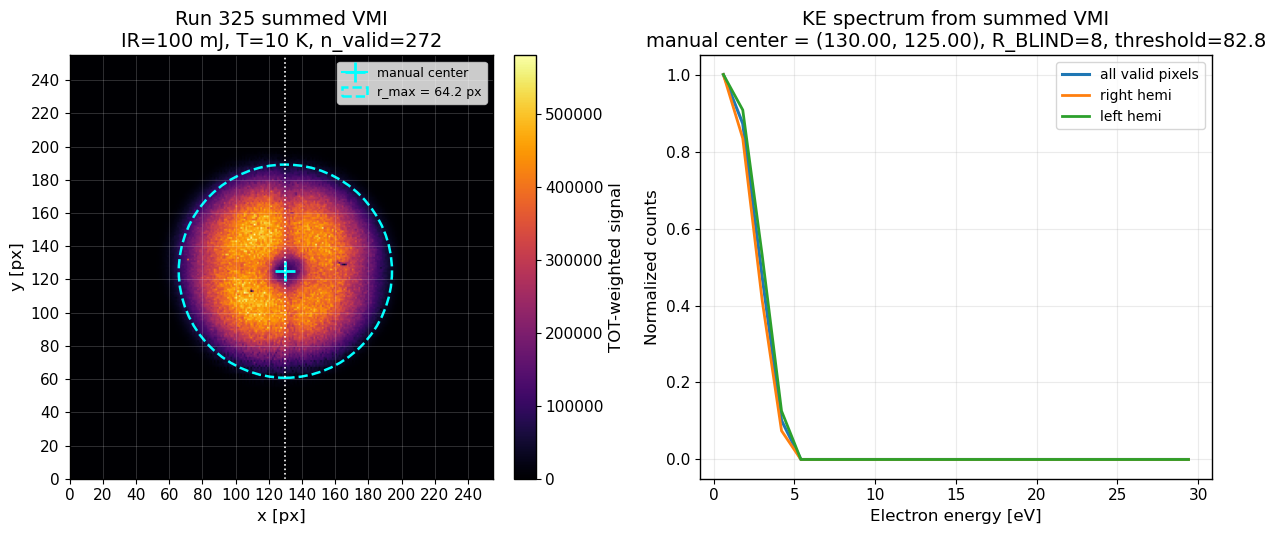

Run 325
manual center      : (130.00, 125.00) px
r_max              : 64.207 px
summed max KE      : 4.180 eV
threshold used     : 82.837
valid pixels all   : 12771
valid pixels  right hemi: 6442
valid pixels   left hemi: 6329


In [146]:
# =========================================================
# CHECK MANUAL CENTER + CIRCLE + SPECTRA:
# full image vs one hemisphere vs opposite hemisphere
# =========================================================

import numpy as np
import matplotlib.pyplot as plt
import h5py
from matplotlib.patches import Circle

# -----------------------
# User parameters
# -----------------------
H5_PATH = r"/p/scratch/pwfa-trojan/medina2/Exp_data/all_runs_vmi_radii.h5"
RUN_TARGET = 325

XC_MANUAL, YC_MANUAL = 130,125 # manual center
PX2_TO_EV = 1.014e-3                    # E[eV] = PX2_TO_EV * r_px^2
R_BLIND = 8                             # blind center radius in px
NBINS = 25
MAX_ENERGY = 30.0                       # eV for plotting
USE_THRESHOLD = True                    # use outer-pixel threshold like in your old cell

# Hemisphere choice:
#   axis = "x"  -> split left/right
#   axis = "y"  -> split bottom/top
#   sign = +1   -> x>=xc or y>=yc
#   sign = -1   -> x<xc  or y<yc
HEMISPHERE_AXIS = "x"
HEMISPHERE_SIGN = +1

# -----------------------
# Load run
# -----------------------
with h5py.File(H5_PATH, "r") as h5:
    run_key = f"runs/run_{RUN_TARGET}"
    if run_key not in h5:
        raise ValueError(f"{run_key} not found")

    g = h5[run_key]
    H_sum = g["summed"]["image"][()].astype(float)
    r_max = float(np.asarray(g["summed"]["radius_px"][()]).squeeze())
    e_max = float(np.asarray(g["summed"]["energy_eV"][()]).squeeze())

    # optional metadata
    run_no = int(g.attrs["run_no"]) if "run_no" in g.attrs else RUN_TARGET
    n_valid_shots = int(g.attrs.get("n_valid_shots", 1))
    ir = float(g.attrs.get("ir_mj", np.nan))
    temp = float(g.attrs.get("temp_K", np.nan))

ny, nx = H_sum.shape
yy, xx = np.indices(H_sum.shape)

xc = XC_MANUAL
yc = YC_MANUAL
r_px = np.sqrt((xx - xc)**2 + (yy - yc)**2)

# -----------------------
# Thresholding (same spirit as your old cell)
# -----------------------
if USE_THRESHOLD:
    r_edge = np.sqrt(max(xc, nx - 1 - xc)**2 + max(yc, ny - 1 - yc)**2)
    mask_outer = (r_px > r_max) & (r_px < r_edge)

    outer_intensities = H_sum[mask_outer].ravel()
    outer_intensities = outer_intensities[outer_intensities > 0]
    outer_sorted = np.sort(outer_intensities)

    if len(outer_sorted) < 3:
        I_threshold = 0.0
    else:
        i_min = 1
        i_max = max(int(0.05 * len(outer_sorted)), 2)
        I_threshold = outer_sorted[i_min:i_max].mean()
else:
    I_threshold = 0.0

# -----------------------
# Base valid mask
# -----------------------
mask_base = (
    np.isfinite(H_sum)
    & (H_sum >= I_threshold)
    & (r_px >= R_BLIND)
    & (r_px <= r_max)
)

# -----------------------
# Hemisphere masks
# -----------------------
if HEMISPHERE_AXIS.lower() == "x":
    mask_hemi_a = xx >= xc if HEMISPHERE_SIGN > 0 else xx < xc
    hemi_label_a = "right hemi" if HEMISPHERE_SIGN > 0 else "left hemi"
    hemi_label_b = "left hemi" if HEMISPHERE_SIGN > 0 else "right hemi"
elif HEMISPHERE_AXIS.lower() == "y":
    mask_hemi_a = yy >= yc if HEMISPHERE_SIGN > 0 else yy < yc
    hemi_label_a = "top hemi" if HEMISPHERE_SIGN > 0 else "bottom hemi"
    hemi_label_b = "bottom hemi" if HEMISPHERE_SIGN > 0 else "top hemi"
else:
    raise ValueError("HEMISPHERE_AXIS must be 'x' or 'y'")

mask_hemi_b = ~mask_hemi_a

mask_all = mask_base
mask_a = mask_base & mask_hemi_a
mask_b = mask_base & mask_hemi_b

# -----------------------
# Function to build weighted KE spectrum
# -----------------------
def make_weighted_ke_hist(mask, H_img, r_img, nbins=150, max_energy=30.0, px2_to_ev=1.014e-3):
    energies_eV = px2_to_ev * r_img[mask]**2
    weights = H_img[mask]

    hist, edges = np.histogram(
        energies_eV,
        bins=nbins,
        range=(0.0, max_energy),
        weights=weights
    )
    centers = 0.5 * (edges[1:] + edges[:-1])
    return centers, hist

E_all, Y_all = make_weighted_ke_hist(mask_all, H_sum, r_px, NBINS, MAX_ENERGY, PX2_TO_EV)
E_a,   Y_a   = make_weighted_ke_hist(mask_a,   H_sum, r_px, NBINS, MAX_ENERGY, PX2_TO_EV)
E_b,   Y_b   = make_weighted_ke_hist(mask_b,   H_sum, r_px, NBINS, MAX_ENERGY, PX2_TO_EV)

# per-shot normalization if desired
Y_all_ps = Y_all / max(n_valid_shots, 1)
Y_a_ps   = Y_a   / max(n_valid_shots, 1)
Y_b_ps   = Y_b   / max(n_valid_shots, 1)

# shape-normalized versions for easier comparison
def safe_norm(y):
    ymax = np.nanmax(y)
    return y / ymax if ymax > 0 else y

Y_all_n = safe_norm(Y_all_ps)
Y_a_n   = safe_norm(Y_a_ps)
Y_b_n   = safe_norm(Y_b_ps)

# -----------------------
# Plot
# -----------------------
fig, ax = plt.subplots(
    1, 2, figsize=(13, 5.5),
    gridspec_kw={"width_ratios": [1.05, 1.0]}
)

# ---- left: VMI
im = ax[0].imshow(
    H_sum,
    origin="lower",
    cmap="inferno",
    aspect="equal"
)

# manual center
ax[0].plot(xc, yc, marker="+", ms=14, mew=2, color="cyan", label="manual center")

# max-radius circle
circ = Circle((xc, yc), r_max, fill=False, ec="cyan", lw=1.8, ls="--", label=f"r_max = {r_max:.1f} px")
ax[0].add_patch(circ)

# hemisphere separator
if HEMISPHERE_AXIS.lower() == "x":
    ax[0].axvline(xc, color="white", lw=1.2, ls=":")
else:
    ax[0].axhline(yc, color="white", lw=1.2, ls=":")

# grid
ax[0].set_xticks(np.arange(0, nx + 1, 20))
ax[0].set_yticks(np.arange(0, ny + 1, 20))
ax[0].grid(True, color="white", alpha=0.18, lw=0.7)

ax[0].set_xlim(0, nx - 1)
ax[0].set_ylim(0, ny - 1)
ax[0].set_xlabel("x [px]")
ax[0].set_ylabel("y [px]")
ax[0].set_title(
    f"Run {run_no} summed VMI\n"
    f"IR={ir:.0f} mJ, T={temp:.0f} K, n_valid={n_valid_shots}"
)
ax[0].legend(loc="upper right", fontsize=9)
fig.colorbar(im, ax=ax[0], fraction=0.046, pad=0.04, label="TOT-weighted signal")

# ---- right: spectra
ax[1].plot(E_all, Y_all_n, lw=2.2, label="all valid pixels")
ax[1].plot(E_a,   Y_a_n,   lw=2.0, label=hemi_label_a)
ax[1].plot(E_b,   Y_b_n,   lw=2.0, label=hemi_label_b)

ax[1].set_xlabel("Electron energy [eV]")
ax[1].set_ylabel("Normalized counts")
ax[1].set_title(
    "KE spectrum from summed VMI\n"
    f"manual center = ({xc:.2f}, {yc:.2f}), R_BLIND={R_BLIND}, threshold={I_threshold:.3g}"
)
ax[1].grid(True, alpha=0.25)
ax[1].legend()

plt.tight_layout()
plt.show()

# -----------------------
# Quick diagnostics
# -----------------------
print(f"Run {RUN_TARGET}")
print(f"manual center      : ({xc:.2f}, {yc:.2f}) px")
print(f"r_max              : {r_max:.3f} px")
print(f"summed max KE      : {e_max:.3f} eV")
print(f"threshold used     : {I_threshold:.6g}")
print(f"valid pixels all   : {mask_all.sum()}")
print(f"valid pixels {hemi_label_a:>11}: {mask_a.sum()}")
print(f"valid pixels {hemi_label_b:>11}: {mask_b.sum()}")

/tmp/ipykernel_476810/2986456426.py:277: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


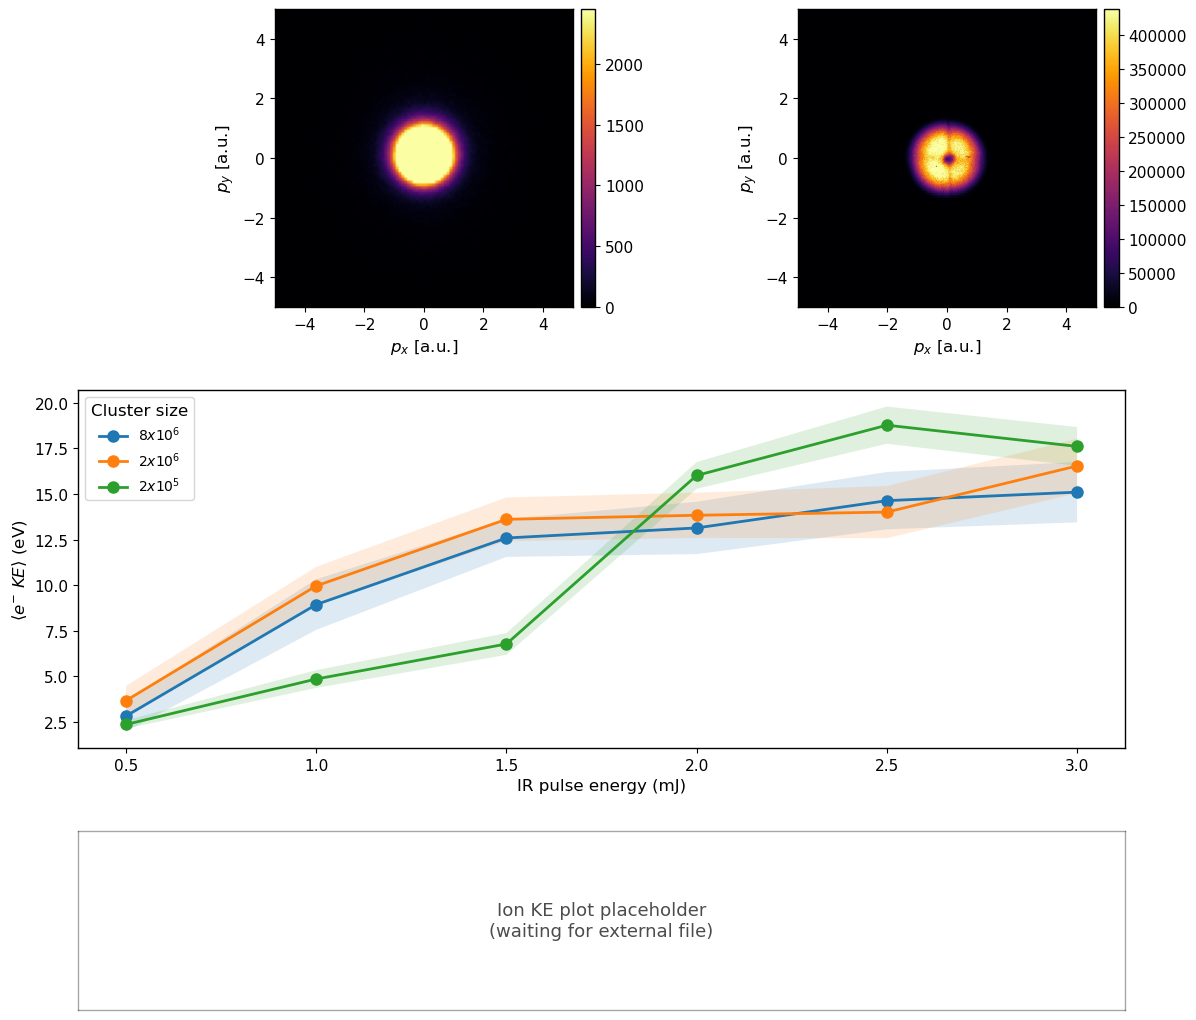

In [212]:
# =========================================================
# FIGURE:
# top    = Sim / Exp VMI
# middle = mean single-shot radius vs IR (experimental)
# bottom = blank placeholder for ions
# =========================================================

import h5py
import numpy as np
import matplotlib.pyplot as plt
import scipy.constants as sc

# -----------------------
# Reset plot style
# -----------------------
import matplotlib as mpl
plt.style.use("default")
mpl.rcdefaults()
mpl.rcParams.update({
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "savefig.facecolor": "white",
    "axes.edgecolor": "black",
    "axes.linewidth": 1.0,
    "axes.grid": False,
    "font.size": 12,
    "axes.titlesize": 14,
    "axes.labelsize": 12,
    "xtick.labelsize": 11,
    "ytick.labelsize": 11,
    "legend.fontsize": 10,
    "legend.frameon": True,
    "image.cmap": "inferno",
})

# -----------------------
# Inputs
# -----------------------
reduced_h5_sim = H5_NEUTRAL
exp_vmi_h5 = r"/p/scratch/pwfa-trojan/medina2/Exp_data/all_runs_vmi_radii.h5"

RUN_TARGET_VMI = 325   # run used for top-right VMI
TIME_INDEX = 18

XC_MANUAL, YC_MANUAL = 119.01, 109.16
PX2_TO_EV = 3.9914e-3
PAD_FACTOR = 2.0

EV_PER_HA = sc.physical_constants["Hartree energy in eV"][0]
p_au_SI = sc.physical_constants["atomic unit of momentum"][0]

# -----------------------
# Simulation VMI
# -----------------------
with h5py.File(reduced_h5_sim, "r") as h5:
    H_pxy_e = h5["spectra/He_e_H_pxy"][TIME_INDEX, :, :]
    p_mid_sim_SI = h5["axes/He_e_p_mid_SI"][:]

p_mid_sim_au = p_mid_sim_SI / p_au_SI
dp_sim_au = p_mid_sim_au[1] - p_mid_sim_au[0]
sim_extent_au = [
    p_mid_sim_au[0] - 0.5 * dp_sim_au,
    p_mid_sim_au[-1] + 0.5 * dp_sim_au,
    p_mid_sim_au[0] - 0.5 * dp_sim_au,
    p_mid_sim_au[-1] + 0.5 * dp_sim_au,
]

# -----------------------
# Experimental VMI for top-right
# -----------------------
with h5py.File(exp_vmi_h5, "r") as h5:
    run_path = f"runs/run_{RUN_TARGET_VMI}"
    if run_path not in h5:
        raise ValueError(f"{run_path} not found in experimental H5")

    H_sum_vmi = h5[f"{run_path}/summed/image"][:].astype(float)

ny, nx = H_sum_vmi.shape
PX2_TO_P_AU = np.sqrt(2.0 * PX2_TO_EV / EV_PER_HA)

exp_extent_au = [
    (0.0      - XC_MANUAL) * PX2_TO_P_AU,
    (nx - 1.0 - XC_MANUAL) * PX2_TO_P_AU,
    (0.0      - YC_MANUAL) * PX2_TO_P_AU,
    (ny - 1.0 - YC_MANUAL) * PX2_TO_P_AU,
]

p_plot_au = max(
    abs(exp_extent_au[0]), abs(exp_extent_au[1]),
    abs(exp_extent_au[2]), abs(exp_extent_au[3]),
) * PAD_FACTOR

# zero-pad experimental image
ny_pad = int(np.ceil(ny * PAD_FACTOR))
nx_pad = int(np.ceil(nx * PAD_FACTOR))
if ny_pad % 2 != ny % 2:
    ny_pad += 1
if nx_pad % 2 != nx % 2:
    nx_pad += 1

H_exp_pad = np.zeros((ny_pad, nx_pad), dtype=float)
y0 = int((ny_pad - ny) // 2)
x0 = int((nx_pad - nx) // 2)
H_exp_pad[y0:y0+ny, x0:x0+nx] = H_sum_vmi

# -----------------------
# Collect run summary for middle panel
# -----------------------
summary = []

with h5py.File(exp_vmi_h5, "r") as h5:
    for run_name in sorted(h5["runs"].keys(), key=lambda s: int(s.split("_")[1])):
        grp = h5[f"runs/{run_name}"]

        # metadata
        run_no = int(grp.attrs["run_no"]) if "run_no" in grp.attrs else int(run_name.split("_")[1])

        # adapt these names if needed
        ir = grp.attrs.get("ir_mj", np.nan)
        temp = grp.attrs.get("temp_K", np.nan)

        # per-shot arrays
        if "shots" not in grp:
            continue
        if "radius_px" not in grp["shots"] or "energy_eV" not in grp["shots"]:
            continue

        r_shots = grp["shots"]["radius_px"][:]
        e_shots = grp["shots"]["energy_eV"][:]

        mr = np.isfinite(r_shots) & (r_shots > 0)
        me = np.isfinite(e_shots) & (e_shots > 0)

        if np.any(mr):
            r_mean = np.mean(r_shots[mr])
            r_std  = np.std(r_shots[mr])
        else:
            r_mean = np.nan
            r_std  = np.nan

        if np.any(me):
            e_mean = np.mean(e_shots[me])
            e_std  = np.std(e_shots[me])
        else:
            e_mean = np.nan
            e_std  = np.nan

        summary.append({
            "run": run_no,
            "ir": float(ir) if np.isfinite(ir) else np.nan,
            "temp": float(temp) if np.isfinite(temp) else np.nan,
            "r_mean": r_mean,
            "r_std": r_std,
            "e_mean": e_mean,
            "e_std": e_std,
        })

# group by temperature
temps = sorted(set(s["temp"] for s in summary if np.isfinite(s["temp"])))

# -----------------------
# Figure layout
# -----------------------
fig = plt.figure(figsize=(13.5,13))
gs = fig.add_gridspec(
    3, 2,
    height_ratios=[1.0, 1.2, 0.6],
    width_ratios=[1, 1],
    hspace=0.3,
    wspace=0.0,   # closer VMI panels
)

ax_sim = fig.add_subplot(gs[0, 0])
ax_exp = fig.add_subplot(gs[0, 1], sharex=ax_sim, sharey=ax_sim)
ax_mid = fig.add_subplot(gs[1, :])
ax_bot = fig.add_subplot(gs[2, :])

# -----------------------
# Top row: VMI panels
# -----------------------
sim_vmax = np.nanpercentile(H_pxy_e, 99.5) if np.any(np.isfinite(H_pxy_e)) else 1.0
exp_vmax = np.nanpercentile(H_exp_pad, 99.5) if np.any(np.isfinite(H_exp_pad)) else 1.0

im0 = ax_sim.imshow(
    H_pxy_e,
    origin="lower",
    cmap="inferno",
    extent=sim_extent_au,
    aspect="equal",
    vmin=0.0,
    vmax=sim_vmax,
)
ax_sim.set_xlabel(r"$p_x$ [a.u.]")
ax_sim.set_ylabel(r"$p_y$ [a.u.]")
ax_sim.set_facecolor("black")

im1 = ax_exp.imshow(
    H_exp_pad,
    origin="lower",
    cmap="inferno",
    extent=[-p_plot_au, p_plot_au, -p_plot_au, p_plot_au],
    aspect="equal",
    vmin=0.0,
    vmax=exp_vmax,
)
ax_exp.set_xlabel(r"$p_x$ [a.u.]")
ax_exp.set_ylabel(r"$p_y$ [a.u.]")
ax_exp.set_facecolor("black")

for ax in (ax_sim, ax_exp):
    ax.set_xlim(-p_plot_au, p_plot_au)
    ax.set_ylim(-p_plot_au, p_plot_au)

# shorter, tighter colorbars inside the figure area
cbar0 = fig.colorbar(im0, ax=ax_sim, fraction=0.040, pad=0.015)
cbar1 = fig.colorbar(im1, ax=ax_exp, fraction=0.040, pad=0.015)

# optionally omit titles
ax_sim.set_title("")
ax_exp.set_title("")

# -----------------------
# Middle row: mean single-shot radius vs IR
# -----------------------
for T in temps:
    
    block = [s for s in summary if np.isfinite(s["ir"]) and s["temp"] == T and np.isfinite(s["r_mean"])]
    block = sorted(block, key=lambda d: d["ir"])
    if not block:
        continue

    x = np.array([b["ir"] for b in block])
    y = np.array([b["r_mean"] for b in block])
    yerr = np.array([b["r_std"] for b in block])
    def sci_label(val):
        exp = int(np.floor(np.log10(val)))
        coeff = val / 10**exp
        if abs(coeff - round(coeff)) < 1e-12:
            coeff = int(round(coeff))
        return rf"${coeff} x 10^{{{exp}}}$"
    
    if T == 12:
        Nlabel = 2e5
    elif T == 10:
        Nlabel = 2e6
    elif T == 9:
        Nlabel = 8e6
    else:
        Nlabel = np.nan
    y= PX2_TO_EV * y**2
    yerr=PX2_TO_EV * yerr**2
    ax_mid.plot(x/100, y, marker="o", lw=2, ms=8,
                label=sci_label(Nlabel))
    ax_mid.fill_between(x/100, y - yerr, y + yerr, alpha=0.15)

ax_mid.set_xlabel("IR pulse energy (mJ)")
ax_mid.set_ylabel(rf"$\langle e^{{-}}$ $KE \rangle$ (eV)")
#ax_mid.set_title("Radius vs IR (mean single-shot)")
#ax_mid.grid(True, alpha=0.15)
ax_mid.legend(title="Cluster size")

# -----------------------
# Bottom row: placeholder for ion KE
# -----------------------
#ax_bot.set_title("Ion kinetic energy spectra")
ax_bot.text(
    0.5, 0.5,
    "Ion KE plot placeholder\n(waiting for external file)",
    ha="center", va="center", fontsize=13, alpha=0.7,
    transform=ax_bot.transAxes
)
ax_bot.set_xticks([])
ax_bot.set_yticks([])
for spine in ax_bot.spines.values():
    spine.set_alpha(0.35)

plt.tight_layout()
plt.show()

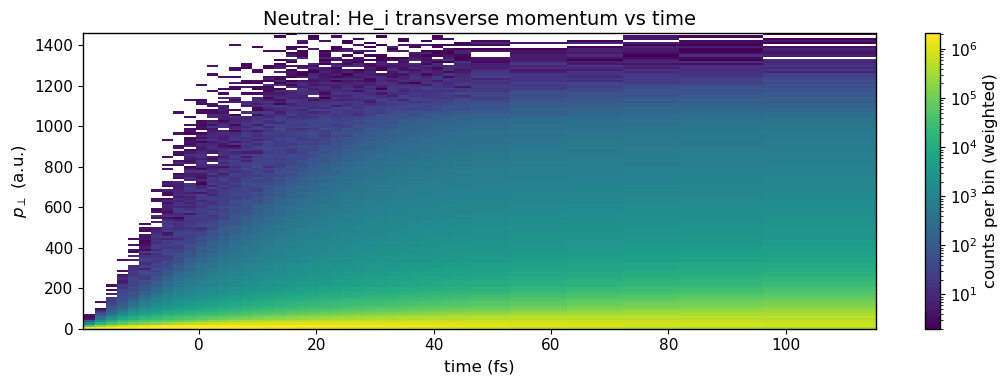

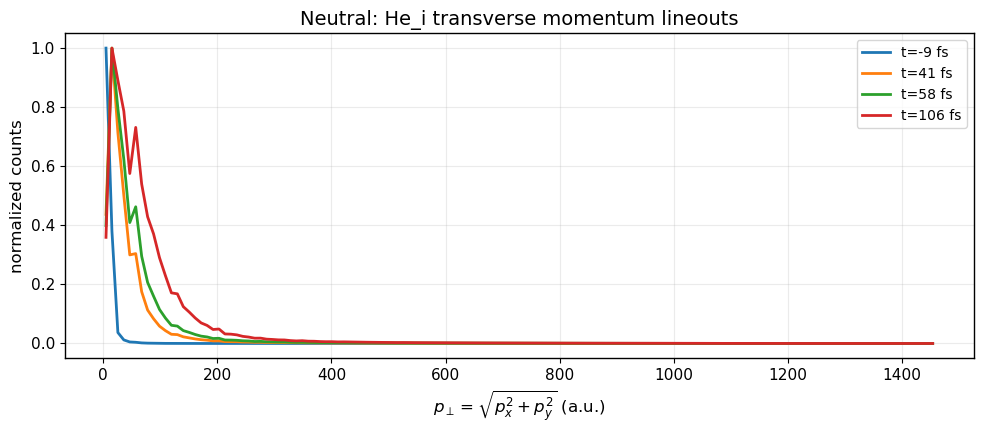

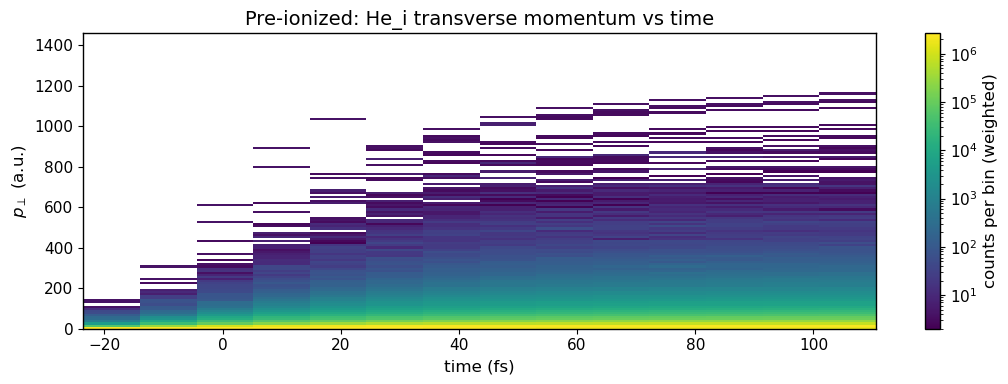

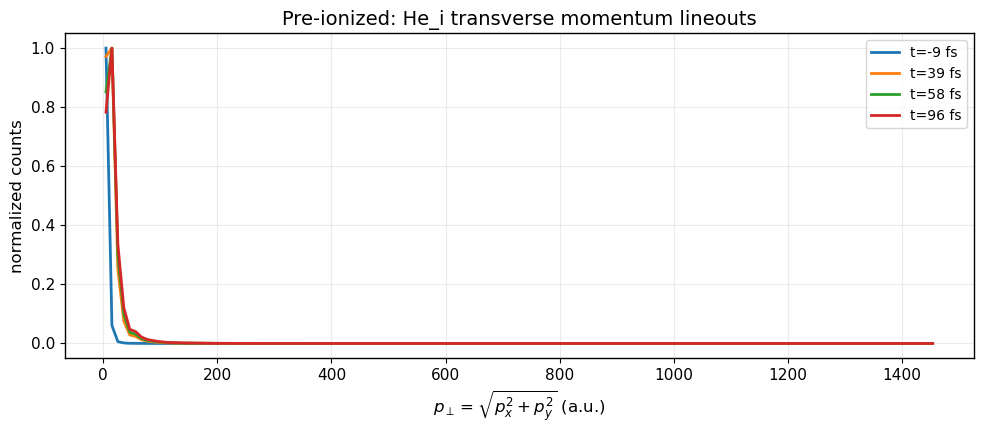

In [224]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.constants as sc

# atomic unit of momentum in SI
P_AU_SI = sc.physical_constants["atomic unit of momentum"][0]

def plot_ion_momentum_lineouts(path, label, species="He_i", times_fs=(0, 50, 200), nbins=140):
    axes = load_axes(path)
    sp = load_spectra(path)

    t = np.asarray(axes["time_fs"])

    # 2D momentum histogram in px,py
    H2 = np.asarray(sp[f"{species}_H_pxy"])   # expected shape (Nt, Np, Np)

    # momentum axis in SI -> convert to a.u.
    p_mid_SI = np.asarray(axes[f"{species}_p_mid_SI"])
    p_mid_au = p_mid_SI / P_AU_SI

    # ensure H2 is (Nt, Np, Np)
    if H2.shape[0] != len(t):
        raise RuntimeError(f"Unexpected shape for {species}_H_pxy: {H2.shape}, expected first dim = len(time_fs)")

    # build px,py mesh in a.u.
    PX, PY = np.meshgrid(p_mid_au, p_mid_au, indexing="xy")
    PPERP = np.sqrt(PX**2 + PY**2)

    pmax = np.nanmax(PPERP)
    edges = np.linspace(0.0, pmax, nbins + 1)
    mid = 0.5 * (edges[1:] + edges[:-1])

    plt.figure(figsize=(10, 4.5))

    for tt in times_fs:
        i = int(np.argmin(np.abs(t - tt)))
        Hxy = H2[i].astype(float)

        # radialize the 2D histogram into p_perp
        hist, _ = np.histogram(PPERP.ravel(), bins=edges, weights=Hxy.ravel())

        # optional normalization for easier comparison
        if np.nanmax(hist) > 0:
            hist = hist / np.nanmax(hist)

        plt.plot(mid, hist, lw=2, label=f"t={t[i]:.0f} fs")

    plt.xlabel(r"$p_\perp = \sqrt{p_x^2+p_y^2}$ (a.u.)")
    plt.ylabel("normalized counts")
    plt.title(f"{label}: {species} transverse momentum lineouts")
    plt.grid(True, alpha=0.25)
    plt.legend()
    plt.tight_layout()
    #plt.show()


def plot_ion_momentum_heatmap(path, label, species="He_i", t_range_fs=None, nbins=140, vmin_p=1.0, vmax_p=99.5):
    axes = load_axes(path)
    sp = load_spectra(path)

    t = np.asarray(axes["time_fs"])
    H2 = np.asarray(sp[f"{species}_H_pxy"])
    p_mid_SI = np.asarray(axes[f"{species}_p_mid_SI"])
    p_mid_au = p_mid_SI / P_AU_SI

    if H2.shape[0] != len(t):
        raise RuntimeError(f"Unexpected shape for {species}_H_pxy: {H2.shape}, expected first dim = len(time_fs)")

    PX, PY = np.meshgrid(p_mid_au, p_mid_au, indexing="xy")
    PPERP = np.sqrt(PX**2 + PY**2)

    pmax = np.nanmax(PPERP)
    p_edges = np.linspace(0.0, pmax, nbins + 1)
    p_mid = 0.5 * (p_edges[1:] + p_edges[:-1])

    # radialize for each time
    Htp = np.zeros((len(t), nbins), dtype=float)
    for i in range(len(t)):
        hist, _ = np.histogram(PPERP.ravel(), bins=p_edges, weights=H2[i].ravel())
        Htp[i] = hist

    # optional time window
    if t_range_fs is not None:
        tmin, tmax = t_range_fs
        m = (t >= tmin) & (t <= tmax)
        t = t[m]
        Htp = Htp[m, :]

    Hplot = Htp.astype(float)
    Hplot[Hplot <= 0] = np.nan
    finite = Hplot[np.isfinite(Hplot)]
    if finite.size == 0:
        raise RuntimeError("All entries are zero/NaN.")

    vmin = np.percentile(finite, vmin_p)
    vmax = np.percentile(finite, vmax_p)
    vmin = max(vmin, 1e-6)
    vmax = max(vmax, vmin * 10)

    # time edges
    t_edges = np.concatenate([0.5 * (t[1:] + t[:-1]), [t[-1] + (t[-1] - t[-2]) / 2]])
    t_edges = np.concatenate([[t[0] - (t[1] - t[0]) / 2], t_edges])

    plt.figure(figsize=(11, 4))
    im = plt.pcolormesh(
        t_edges, p_edges, Hplot.T,
        shading="auto",
        cmap="viridis",
        norm=plt.matplotlib.colors.LogNorm(vmin=vmin, vmax=vmax)
    )
    plt.colorbar(im, label="counts per bin (weighted)")
    plt.xlabel("time (fs)")
    plt.ylabel(r"$p_\perp$ (a.u.)")
    plt.title(f"{label}: {species} transverse momentum vs time")
    plt.tight_layout()
    plt.show()


# --- run for both simulations ---
for p, label in [(H5_NEUTRAL, "Neutral"), (H5_IONIZED, "Pre-ionized")]:
    plot_ion_momentum_heatmap(p, label, species="He_i", t_range_fs=(-20, 150))
    plot_ion_momentum_lineouts(p, label, species="He_i", times_fs=(-10, 40, 60, 100))

/tmp/ipykernel_476810/1594553034.py:347: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


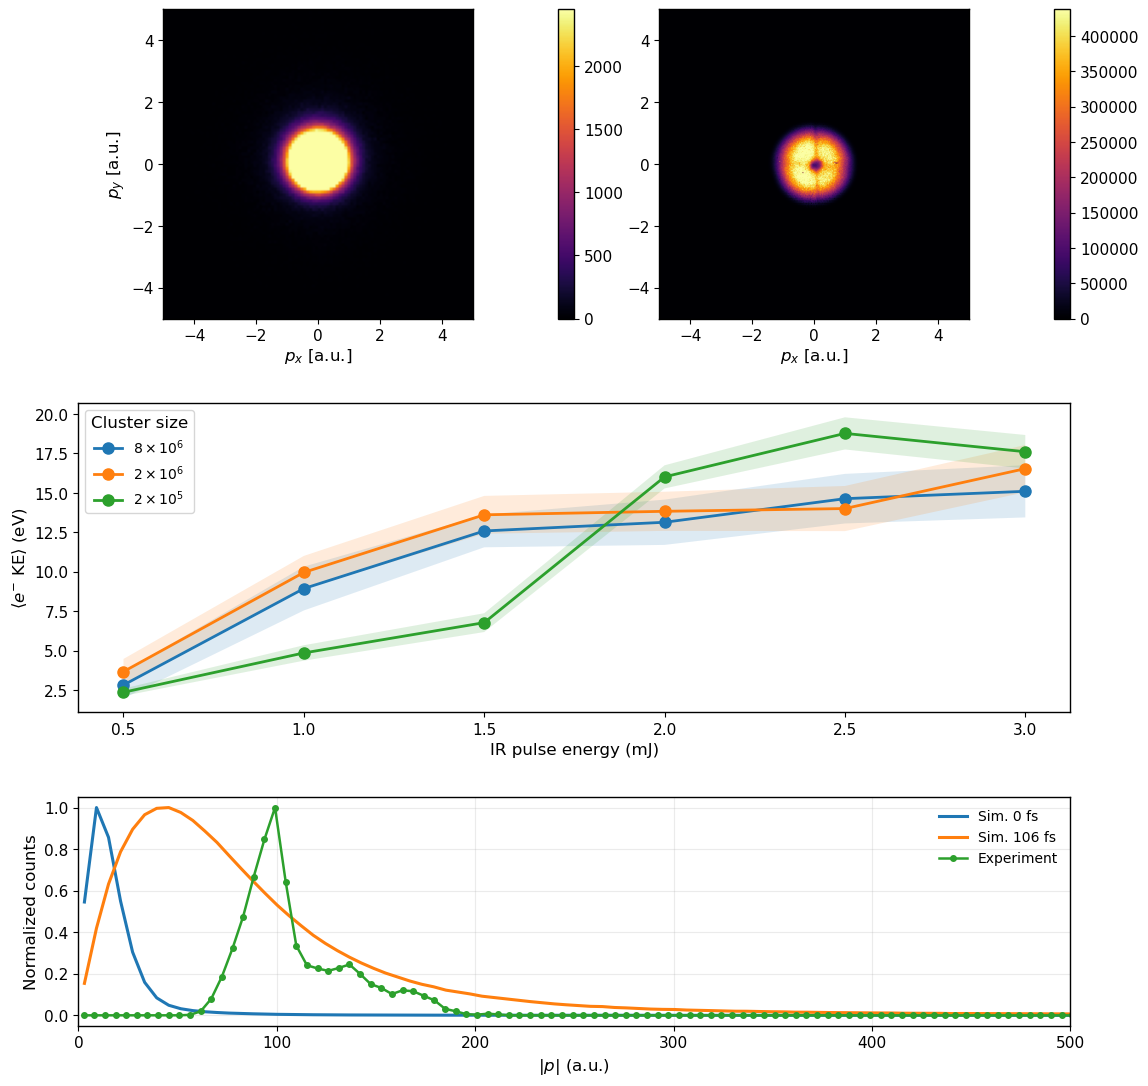

In [253]:
# =========================================================
# FIGURE:
# top    = Sim / Exp VMI
# middle = mean single-shot max electron KE vs IR (experimental)
# bottom = ion momentum distribution (simulation vs experiment)
# =========================================================

import h5py
import numpy as np
import matplotlib.pyplot as plt
import scipy.constants as sc
import matplotlib as mpl

from nanoplasma_ana import NanoPlasmaRun

# -----------------------
# Reset plot style
# -----------------------
plt.style.use("default")
mpl.rcdefaults()
mpl.rcParams.update({
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "savefig.facecolor": "white",
    "axes.edgecolor": "black",
    "axes.linewidth": 1.0,
    "axes.grid": False,
    "font.size": 12,
    "axes.titlesize": 14,
    "axes.labelsize": 12,
    "xtick.labelsize": 11,
    "ytick.labelsize": 11,
    "legend.fontsize": 10,
    "legend.frameon": True,
    "image.cmap": "inferno",
})

# -----------------------
# Inputs
# -----------------------
reduced_h5_sim = H5_NEUTRAL
exp_vmi_h5 = r"/p/scratch/pwfa-trojan/medina2/Exp_data/all_runs_vmi_radii.h5"

# raw sim for ion momentum
run = NanoPlasmaRun(
    path="/p/scratch/jureap18/medina2/2026_nanoplasma/004_Neutral_Smallsteps/simOutput",
    laser_peak_at_target=89603
)

RUN_TARGET_VMI = 325
TIME_INDEX = 18

XC_MANUAL, YC_MANUAL = 119.01, 109.16
PX2_TO_EV = 3.9914e-3
PAD_FACTOR = 2.0

# ion panel inputs
ION_SPECIES = "He_i"
SIM_ION_TIMES_FS = (0, 120)
EXP_ION_H5 = "all_runs_ion_kinematics.h5"
RUN_EXP_ION = 236
EXP_ION_LABEL = "Experiment"
ION_NBINS = 1000
ION_XMAX = 500

EV_PER_HA = sc.physical_constants["Hartree energy in eV"][0]
p_au_SI = sc.physical_constants["atomic unit of momentum"][0]

# -----------------------
# Simulation VMI
# -----------------------
with h5py.File(reduced_h5_sim, "r") as h5:
    H_pxy_e = h5["spectra/He_e_H_pxy"][TIME_INDEX, :, :]
    p_mid_sim_SI = h5["axes/He_e_p_mid_SI"][:]

p_mid_sim_au = p_mid_sim_SI / p_au_SI
dp_sim_au = p_mid_sim_au[1] - p_mid_sim_au[0]
sim_extent_au = [
    p_mid_sim_au[0] - 0.5 * dp_sim_au,
    p_mid_sim_au[-1] + 0.5 * dp_sim_au,
    p_mid_sim_au[0] - 0.5 * dp_sim_au,
    p_mid_sim_au[-1] + 0.5 * dp_sim_au,
]

# -----------------------
# Experimental VMI for top-right
# -----------------------
with h5py.File(exp_vmi_h5, "r") as h5:
    run_path = f"runs/run_{RUN_TARGET_VMI}"
    if run_path not in h5:
        raise ValueError(f"{run_path} not found in experimental H5")
    H_sum_vmi = h5[f"{run_path}/summed/image"][:].astype(float)

ny, nx = H_sum_vmi.shape
PX2_TO_P_AU = np.sqrt(2.0 * PX2_TO_EV / EV_PER_HA)

exp_extent_au = [
    (0.0      - XC_MANUAL) * PX2_TO_P_AU,
    (nx - 1.0 - XC_MANUAL) * PX2_TO_P_AU,
    (0.0      - YC_MANUAL) * PX2_TO_P_AU,
    (ny - 1.0 - YC_MANUAL) * PX2_TO_P_AU,
]



# zero-pad experimental image
ny_pad = int(np.ceil(ny * PAD_FACTOR))
nx_pad = int(np.ceil(nx * PAD_FACTOR))
if ny_pad % 2 != ny % 2:
    ny_pad += 1
if nx_pad % 2 != nx % 2:
    nx_pad += 1

H_exp_pad = np.zeros((ny_pad, nx_pad), dtype=float)
y0 = int((ny_pad - ny) // 2)
x0 = int((nx_pad - nx) // 2)
H_exp_pad[y0:y0+ny, x0:x0+nx] = H_sum_vmi

# -----------------------
# Collect run summary for middle panel
# -----------------------
summary = []
with h5py.File(exp_vmi_h5, "r") as h5:
    for run_name in sorted(h5["runs"].keys(), key=lambda s: int(s.split("_")[1])):
        grp = h5[f"runs/{run_name}"]

        run_no = int(grp.attrs["run_no"]) if "run_no" in grp.attrs else int(run_name.split("_")[1])
        ir = grp.attrs.get("ir_mj", np.nan)
        temp = grp.attrs.get("temp_K", np.nan)

        if "shots" not in grp:
            continue
        if "radius_px" not in grp["shots"] or "energy_eV" not in grp["shots"]:
            continue

        r_shots = grp["shots"]["radius_px"][:]
        e_shots = grp["shots"]["energy_eV"][:]

        mr = np.isfinite(r_shots) & (r_shots > 0)
        me = np.isfinite(e_shots) & (e_shots > 0)

        if np.any(mr):
            r_mean = np.mean(r_shots[mr])
            r_std  = np.std(r_shots[mr])
        else:
            r_mean = np.nan
            r_std  = np.nan

        if np.any(me):
            e_mean = np.mean(e_shots[me])
            e_std  = np.std(e_shots[me])
        else:
            e_mean = np.nan
            e_std  = np.nan

        summary.append({
            "run": run_no,
            "ir": float(ir) if np.isfinite(ir) else np.nan,
            "temp": float(temp) if np.isfinite(temp) else np.nan,
            "r_mean": r_mean,
            "r_std": r_std,
            "e_mean": e_mean,
            "e_std": e_std,
        })

temps = sorted(set(s["temp"] for s in summary if np.isfinite(s["temp"])))

# -----------------------
# Figure layout
# -----------------------
fig = plt.figure(figsize=(12.8, 13.2))

outer = fig.add_gridspec(
    3, 1,
    height_ratios=[1.15, 1.15, 0.85],
    hspace=0.30
)

# top row: image, cbar, image, cbar  -> much tighter
top = outer[0].subgridspec(
    1, 4,
    width_ratios=[1.0, 0.035, 1.0, 0.035],
    wspace=0
)

ax_sim  = fig.add_subplot(top[0, 0])
cax_sim = fig.add_subplot(top[0, 1])
ax_exp  = fig.add_subplot(top[0, 2], sharex=ax_sim, sharey=ax_sim)
cax_exp = fig.add_subplot(top[0, 3])

# middle and bottom rows span full width
ax_mid = fig.add_subplot(outer[1, 0])
ax_bot = fig.add_subplot(outer[2, 0])

# -----------------------
# Top row: VMI panels
# -----------------------
sim_vmax = np.nanpercentile(H_pxy_e, 99.5) if np.any(np.isfinite(H_pxy_e)) else 1.0
exp_vmax = np.nanpercentile(H_exp_pad, 99.5) if np.any(np.isfinite(H_exp_pad)) else 1.0

im0 = ax_sim.imshow(
    H_pxy_e,
    origin="lower",
    cmap="inferno",
    extent=sim_extent_au,
    aspect="equal",
    vmin=0.0,
    vmax=sim_vmax,
)
ax_sim.set_xlabel(r"$p_x$ [a.u.]")
ax_sim.set_ylabel(r"$p_y$ [a.u.]")
ax_sim.set_facecolor("black")

im1 = ax_exp.imshow(
    H_exp_pad,
    origin="lower",
    cmap="inferno",
    extent=[-p_plot_au, p_plot_au, -p_plot_au, p_plot_au],
    aspect="equal",
    vmin=0.0,
    vmax=exp_vmax,
)
ax_exp.set_xlabel(r"$p_x$ [a.u.]")
ax_exp.set_ylabel(r"$p_y$ [a.u.]")
ax_exp.set_facecolor("black")

for ax in (ax_sim, ax_exp):
    ax.set_xlim(-p_plot_au, p_plot_au)
    ax.set_ylim(-p_plot_au, p_plot_au)
    ax.set_aspect("equal", adjustable="box")
    ax.margins(0)

fig.colorbar(im0, cax=cax_sim)
fig.colorbar(im1, cax=cax_exp)
ax_sim.set_title("")
ax_exp.set_title("")

ax_sim.set_xlabel(r"$p_x$ [a.u.]", labelpad=2)
ax_sim.set_ylabel(r"$p_y$ [a.u.]", labelpad=2)

ax_exp.set_xlabel(r"$p_x$ [a.u.]", labelpad=2)
ax_exp.set_ylabel(r"", labelpad=2)

# -----------------------
# Middle row: mean single-shot max electron KE vs IR
# -----------------------
def sci_label(val):
    exp = int(np.floor(np.log10(val)))
    coeff = val / 10**exp
    if abs(coeff - round(coeff)) < 1e-12:
        coeff = int(round(coeff))
    return rf"${coeff} \times 10^{{{exp}}}$"

for T in temps:
    block = [s for s in summary if np.isfinite(s["ir"]) and s["temp"] == T and np.isfinite(s["r_mean"])]
    block = sorted(block, key=lambda d: d["ir"])
    if not block:
        continue

    x = np.array([b["ir"] for b in block])
    y = np.array([b["r_mean"] for b in block])
    yerr = np.array([b["r_std"] for b in block])

    if T == 12:
        Nlabel = 2e5
    elif T == 10:
        Nlabel = 2e6
    elif T == 9:
        Nlabel = 8e6
    else:
        Nlabel = np.nan

    y = PX2_TO_EV * y**2
    yerr = PX2_TO_EV * yerr**2

    ax_mid.plot(x/100, y, marker="o", lw=2, ms=8, label=sci_label(Nlabel))
    ax_mid.fill_between(x/100, y - yerr, y + yerr, alpha=0.15)

ax_mid.set_xlabel("IR pulse energy (mJ)")
ax_mid.set_ylabel(r"$\langle e^{-}\ \mathrm{KE}\rangle$ (eV)")
ax_mid.legend(title="Cluster size")

# -----------------------
# Bottom row: ion momentum (simulation vs experiment)
# -----------------------
def extract_step_from_filename(filename):
    return int((filename.rpartition('_')[2]).rpartition('.')[0])

steps = np.array([extract_step_from_filename(fn) for fn in run.files], dtype=int)
times_all_fs = np.array([run.time_fs_from_step(st) for st in steps], dtype=float)

sel_idx = []
for tt in SIM_ION_TIMES_FS:
    i = int(np.argmin(np.abs(times_all_fs - tt)))
    if i not in sel_idx:
        sel_idx.append(i)

pmax_found = 0.0
for i in sel_idx:
    fn = run.files[i]
    step = steps[i]
    px, py, pz, w = run._read_momentum_and_weight(fn, step, ION_SPECIES)
    if px is None:
        continue
    p_abs_au = np.sqrt(px*px + py*py + pz*pz) / p_au_SI
    if p_abs_au.size > 0:
        pmax_found = float(np.maximum(pmax_found, np.nanmax(p_abs_au)))

P_MAX_AU = 1.05 * pmax_found if pmax_found > 0 else 1.0
edges = np.linspace(0.0, P_MAX_AU, ION_NBINS + 1)
mid = 0.5 * (edges[1:] + edges[:-1])

# simulation curves
for i in sel_idx:
    fn = run.files[i]
    step = steps[i]
    t_fs = times_all_fs[i]

    px, py, pz, w = run._read_momentum_and_weight(fn, step, ION_SPECIES)
    if px is None:
        continue

    p_abs_au = np.sqrt(px*px + py*py + pz*pz) / p_au_SI
    hist, _ = np.histogram(p_abs_au, bins=edges, weights=w)

    if np.nanmax(hist) > 0:
        hist = hist / np.nanmax(hist)

    ax_bot.plot(mid, hist, lw=2.2, label=f"Sim. {t_fs:.0f} fs")

# experimental curve
with h5py.File(EXP_ION_H5, "r") as h5:
    c_exp = h5[f"runs/run_{RUN_EXP_ION}/hist/counts_P"][:].astype(float)
    p_exp = h5[f"runs/run_{RUN_EXP_ION}/hist/centers_P"][:]

if np.nanmax(c_exp) > 0:
    c_exp = c_exp / np.nanmax(c_exp)

ax_bot.plot(p_exp, c_exp, "o-", ms=4, lw=1.8, label=EXP_ION_LABEL)

ax_bot.set_xlabel(r"$|p|$ (a.u.)")
ax_bot.set_ylabel("Normalized counts")
ax_bot.set_xlim(0, ION_XMAX)
ax_bot.grid(True, alpha=0.25)
ax_bot.legend(frameon=False)     

plt.tight_layout()
#plt.subplots_adjust(left=0.08, right=0.97, top=0.98, bottom=0.06)
plt.savefig("Fig4.png", dpi=300, bbox_inches="tight")
plt.show()

In [118]:
import matplotlib as mpl
import matplotlib.pyplot as plt

# --- Try SciencePlots first (preferred) ---
try:
    import scienceplots  # required before plt.style.use('science') in newer versions
    plt.style.use(["science", "grid", "no-latex"])
    # You can also try: ["science", "nature", "no-latex"] depending on what’s available in your install.
    USING = "SciencePlots"
except Exception as e:
    USING = f"rcParams fallback (SciencePlots not available: {type(e).__name__})"

    mpl.rcParams.update({
        # Figure / saving
        "figure.dpi": 150,
        "savefig.dpi": 300,
        "savefig.bbox": "tight",
        "savefig.pad_inches": 0.02,

        # Fonts (LaTeX-like look without requiring LaTeX)
        "font.family": "serif",
        "font.size": 11,
        "axes.titlesize": 12,
        "axes.labelsize": 11,
        "xtick.labelsize": 10,
        "ytick.labelsize": 10,
        "legend.fontsize": 10,

        # Axes
        "axes.linewidth": 0.8,
        "axes.spines.top": False,
        "axes.spines.right": False,
        "axes.grid": False,

        # Grid (light, paper-style)
        "grid.alpha": 0.25,
        "grid.linewidth": 0.6,
        "grid.linestyle": "-",

        # Lines
        "lines.linewidth": 2.0,
        "lines.markersize": 5,

        # Ticks
        "xtick.direction": "in",
        "ytick.direction": "in",
        "xtick.major.size": 4,
        "ytick.major.size": 4,
        "xtick.minor.size": 2.5,
        "ytick.minor.size": 2.5,
        "xtick.major.width": 0.8,
        "ytick.major.width": 0.8,
        "xtick.minor.width": 0.6,
        "ytick.minor.width": 0.6,
        "xtick.minor.visible": True,
        "ytick.minor.visible": True,

        # Legend
        "legend.frameon": False,
    })

print("Plot style:", USING)
mpl.rcParams.update({
    "axes.spines.top": True,
    "axes.spines.right": True,
    "axes.spines.left": True,
    "axes.spines.bottom": True,
    "axes.linewidth": 0.9,
})



Plot style: rcParams fallback (SciencePlots not available: ModuleNotFoundError)
